<font face="Times New Roman" size=5>
<div dir=rtl align="center">
<font face="Times New Roman" size=5>
In The Name of God
</font>
<br>
<img src="https://logoyar.com/content/wp-content/uploads/2021/04/sharif-university-logo.png" alt="University Logo" width="150" height="150">
<br>
<font face="Times New Roman" size=4 align=center>
Sharif University of Technology - Department of Electrical Engineering
</font>
<br>
<font color="#008080" size=6>
Communication Systems
</font>
<hr/>
<font color="#800080" size=5>
Assignment 2
<br>
</font>
<font size=5>
Instructor: Dr. Pakravan
<br>
</font>
<font size=4>
Fall 2025
<br>
</font>

<hr>
<br>
</font>
<font face="Times New Roman" size=4 align=center>
Feel free to ask your questions in Telegram : @YadollahiAlii
</font>
<br>
<hr>
</div></font>

Name = Hamed Batani

StudentId = 402101339

# Import Libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sounddevice as sd
from scipy.io.wavfile import write
from scipy.io.wavfile import read
from IPython.display import Audio


# Question 1: Amplitude Modulation


Consider the following signal


$
m(t) = e^{-6t}\bigl[u(t-4) - u(t-8)\bigr]
     + e^{6t}\bigl[u(-t-4) - u(-t-8)\bigr]
$


## Task 1.1
First, plot the signal in the time and frequency domains and declare its bandwidth; Then
sample the signal at an appropriate rate. Explain how this rate is obtained.

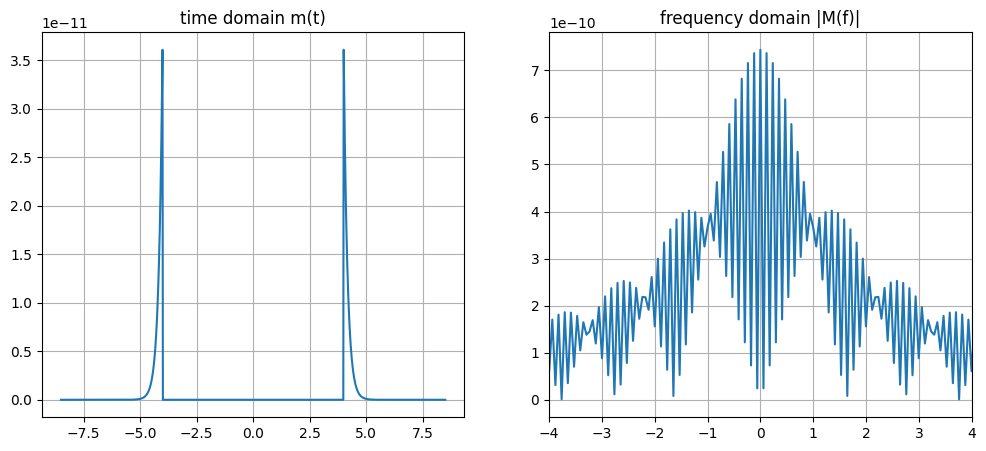

Sampling Rate: 10 Hz


In [3]:
# first we define time vector
t = np.linspace(-8.5, 8.5, 1000)
dt = t[1] - t[0]

# the signal itself
term1 = np.exp(-6*t) * ((t >= 4) & (t <= 8))
term2 = np.exp(6*t) * ((t <= -4) & (t >= -8))
m_t = term1 + term2

# Ploting the time domian
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(t, m_t)
plt.title("time domain m(t)")
plt.grid()

# frequancy domain ( Fourier transform ) using FFT
M_f = np.fft.fftshift(np.fft.fft(m_t))
freqs = np.fft.fftshift(np.fft.fftfreq(len(t), d=dt))

# plotting frequcny domain
plt.subplot(1, 2, 2)
plt.plot(freqs, np.abs(M_f))
plt.title("frequency domain |M(f)|")
plt.xlim(-4, 4) # Zoom in
plt.grid()
plt.show()

# Sampling
fs_nyquist = 10 # estimated bandwidth
print(f"Sampling Rate: {fs_nyquist} Hz")


## code structure

- A dense time vector is defined to approximate a continuous-time signal.
- The signal is constructed using exponential terms multiplied by time windows,
  which implement the unit-step functions.
- The time-domain plot verifies that the signal exists only on
  4 ≤ t ≤ 8 and −8 ≤ t ≤ −4.
- The frequency-domain representation is obtained using the FFT as a numerical
  approximation of the continuous-time Fourier Transform.

Because the signal is time-limited, it is not strictly bandlimited, and its
spectrum extends to infinite frequency. Therefore, an effective bandwidth is
used instead of an exact one.


## fourier transform derivation  ( a quick sanity check for our plot )

Split the signal using linearity:

$
m(t)=m_1(t)+m_2(t)
$

$
m_1(t)=e^{-6t}[u(t-4)-u(t-8)]
$

$
m_2(t)=e^{6t}[u(-t-4)-u(-t-8)]
$

Rewrite the first term:

$
m_1(t)=e^{-6t}u(t-4)-e^{-6t}u(t-8)
$

Using the known transform

$
\mathcal{F}\{e^{-at}u(t)\}=\frac{1}{a+j\omega}
$

and the time-shift property

$
\mathcal{F}\{x(t-t_0)\}=e^{-j\omega t_0}X(\omega)
$

the transform of \(m_1(t)\) is

$
M_1(\omega)=\frac{e^{-24}e^{-j4\omega}-e^{-48}e^{-j8\omega}}{6+j\omega}
$

The second term is a time-reversed version of the first:

$
m_2(t)=m_1(-t)
$

Using the time-reversal property

$
\mathcal{F}\{x(-t)\}=X(-\omega)
$

gives

$
M_2(\omega)=\frac{e^{-24}e^{j4\omega}-e^{-48}e^{j8\omega}}{6-j\omega}
$

The total Fourier Transform is

$
M(\omega)=M_1(\omega)+M_2(\omega)
$

which totally matches our plot

## bandwidth and nyquist rate

Since the spectrum never becomes exactly zero, an effective bandwidth B is
defined as the frequency where the magnitude falls below a chosen threshold
(e.g., −40 dB). The sampling frequency is then selected using the Nyquist
criterion:

$
f_s \ge 2B
$

The FFT-based spectrum in the code is used to estimate B numerically, and the
sampling rate is chosen accordingly.


## Task 1.2
By defining suitable parameters, modulate this signal with AM modulation. Plot the modulated
signal and its spectrum.

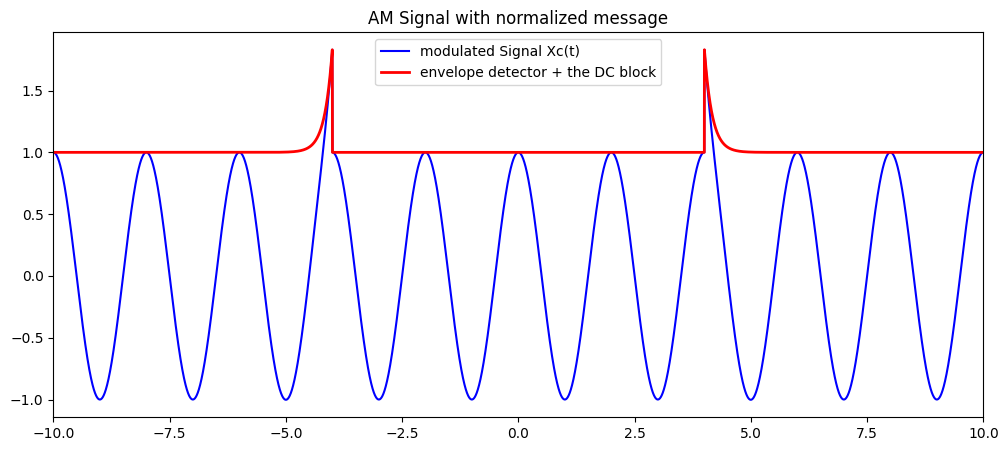

Text(0.5, 1.0, 'x_c(t) = (1 + k_a m(t)) cos(2π f_c t)')

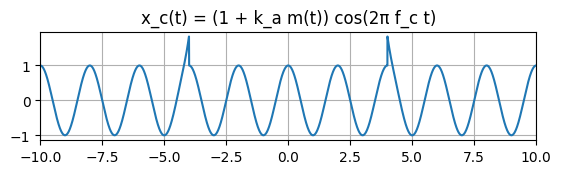

In [10]:
# 1. setting up the time vector
t = np.linspace(-10, 10, 10000)
dt = t[1] - t[0]

# 2. defining the signal ( m (t) )
m1 = np.exp(-6*t) * ((t >= 4) & (t <= 8))
m2 = np.exp(6*t) * ((t >= -8) & (t <= -4))
m_t = m1 + m2

# 3. normalizing signal so the peak is 1 ( explained in markdown below )
if np.max(np.abs(m_t)) > 0:
    m_t = m_t / np.max(np.abs(m_t))

# 4. AM parameters ( explained in markdown below )
fc = 5000
ka = 0.83

# 5. modulation signal x_c = Am (1+ka*m(t) )  cos ( 2*pi*fc*t )
carrier = np.cos(2 * np.pi * fc * t)
x_c = (1 + ka * m_t) * carrier

# 6. Plotting
plt.figure(figsize=(12, 5))
plt.plot(t, x_c, color='blue', label='modulated Signal Xc(t)')
plt.plot(t, (1 + ka * m_t), 'r', linewidth=2, label='envelope detector + the DC block')
plt.title("AM Signal with normalized message")
plt.xlim(-10, 10)
plt.legend()
plt.show()




This code constructs the message signal \(m(t)\), applies conventional AM modulation, and plots the resulting modulated waveform together with its envelope to verify correct operation.

### Message signal definition
The message \(m(t)\) is formed from two time-limited exponential segments,
Boolean masks are used to confine each exponential to its active interval, making the signal exactly zero elsewhere.



### normalization of \(m(t)\)
Before modulation, the message signal is normalized to unit peak magnitude
Without normalization, the AM waveform appeared as an almost flat cosine because the message amplitude was much smaller than the carrier amplitude. Normalization magnifies the envelope variations, improving visual clarity while preserving the signal shape.



### choice of AM parameters
- **Carrier frequency \(f_c=5000\) Hz:** selected such that (f_c >>> B\), where \(B\) is the message bandwidth. This ensures well-separated carrier and sidebands in the spectrum.
- **Modulation index \(k_a=0.83\):** chosen below unity to avoid over-modulation while still producing a clearly visible envelope.






## Task 1.3
The circuit shown in the following figure is the simplest circuit to detect the signal envelope. Introduce the
time constant and explain its effect on the output corresponding to this circuit. What effect
do you think putting a resistor in series with a diode has on the output?

![fig1:Envelope Detector](fig1.png)


### time constant
in the envelope detector circuit, the time constant is defined as

$
\tau = rc
$

it describes how fast the capacitor charges through the diode and how slowly it discharges through the resistor. therefore, it directly controls how the output $\hat{m}(t)$ follows the envelope of the am signal.



### effect of the time constant on the output
the diode charges the capacitor to the peaks of the carrier, while the resistor allows the capacitor to discharge between peaks.

- if $rc$ is too small
  the capacitor discharges too quickly, so carrier riples appear at the output and the envelope is not properly smoothed.

- if $rc$ is too large
  the capacitor discharges too slowly and cannot follow fast variations of the envelope, which results in diagonal clipping.

according to doctors slides, the correct condition is

$
\omega_c \ll \frac{1}{rc} \ll \omega_m
$

this key condition is valid because $\frac{1}{rc}$ must be much smaller than the carrier frequency to suppress carrier ripple, and much larger than the message frequency so the capacitor can accurately follow the envelope variations.



### effect of adding a resistor in series with the diode
adding a resistor in series with the diode slows down the charging of the capacitor. this reduces the peak value reached by the cepacitor and degrades envelope tracking, especially for rapidly changing envelopes. as a result, the detected signal becomes more distorted compared to the ideal case.



in page 28 of the analog slides of doctor, the case where $rc$ is too large is shown. the envelope detector output fails to follow the true envelope and instead forms straight-line segments between carrier peaks, clearly illustrating diagonal clipping.


## Task 1.4
Write a function that takes the input signal, the time constant and the initial value of the
output and gives the corresponding output. (for the detector in the previous part)

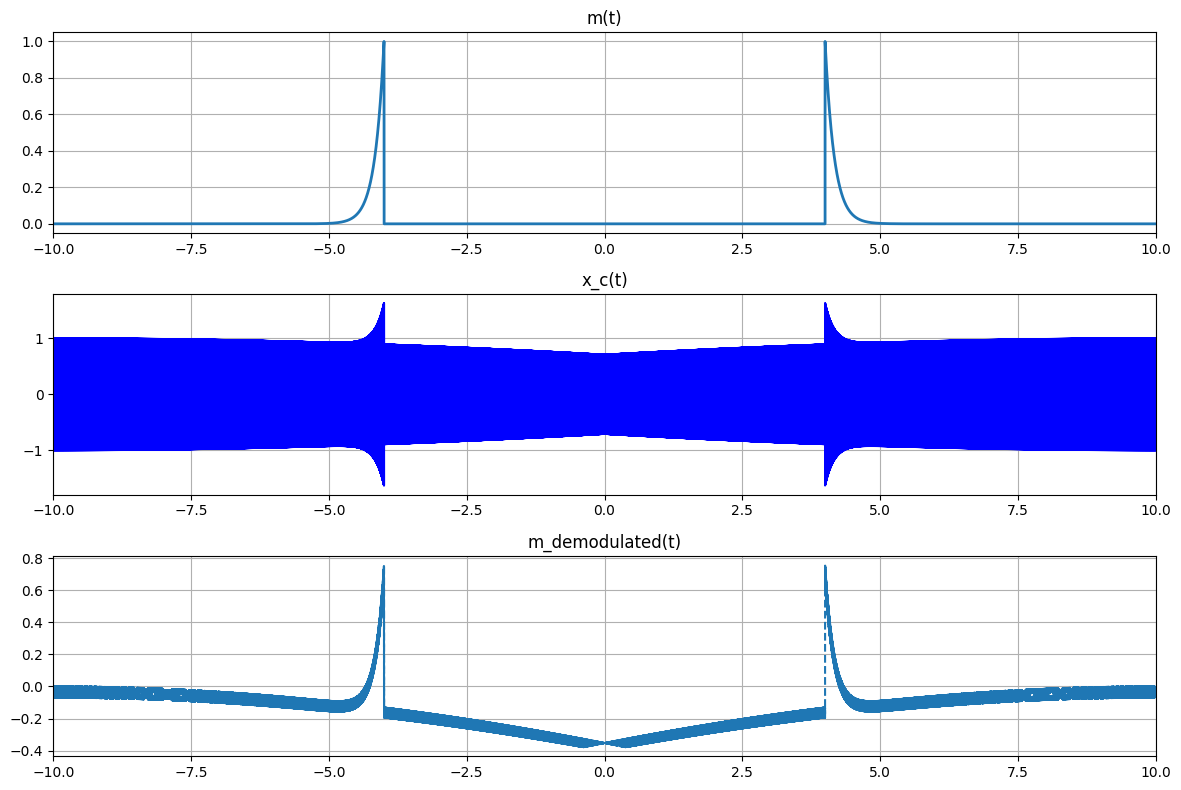

In [13]:
def envelope_detector(x, t, rc, y0):
    x = np.asarray(x)
    t = np.asarray(t)
    dt = t[1] - t[0]

    xr = np.abs(x)

    y = np.zeros_like(xr)
    y[0] = y0

    a = np.exp(-dt / rc)

    for n in range(1, len(xr)):
        yd = y[n - 1] * a
        y[n] = max(xr[n], yd)

    return y

# 1) time
t = np.linspace(-10, 10, 400000)
dt = t[1] - t[0]
fs = 1 / dt

# 2) message
m1 = np.exp(-6*t) * ((t >= 4) & (t <= 8))
m2 = np.exp(6*t) * ((t >= -8) & (t <= -4))
m_t = m1 + m2

# 3) normalize
pk = np.max(np.abs(m_t))
if pk > 0:
    m_t = m_t / pk

# 4) am params
fc = 5000
ka = 0.83

# 5) modulate
carrier = np.cos(2 * np.pi * fc * t)
x_c = (1 + ka * m_t) * carrier

# 6) envelope detect : rc was chosen from an estimated message bandwidth so that the time constant is large enough to smooth the carrier ripple but small enough to follow the envelope variations.`

b = 190
rc = 1 / (2 * np.pi * b)
y_env = envelope_detector(x_c, t, rc, y0=np.abs(x_c[0]))

# 7) recover
m_demodulated = (y_env - 1) / ka

# 8) plot (m, x_c, m_demodulated)
plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(t, m_t, linewidth=2)
plt.xlim(-10, 10)
plt.grid(True)
plt.title("m(t)")

plt.subplot(3, 1, 2)
plt.plot(t, x_c, color="blue")
plt.xlim(-10, 10)
plt.grid(True)
plt.title("x_c(t)")

plt.subplot(3, 1, 3)
plt.plot(t, m_demodulated, "--")
plt.xlim(-10, 10)
plt.grid(True)
plt.title("m_demodulated(t)")

plt.tight_layout()
plt.show()


the same message was first used to build the am signal:

$
x_c(t) = (1 + k_a m(t))\cos(2\pi f_c t)
$

to demodulate with an envelope detector, the input was rectified and then passed through the rc discharge rule. in code, the detector uses:

- rectification: $|x_c(t)|$
- exponential discharge between peaks with factor $a=e^{-dt/rc}$
- peak tracking via the rule $y[n]=\max(|x[n]|,\;a\,y[n-1])$

this produces an estimate of the envelope:

$
y_{env}(t)\approx 1 + k_a m(t)
$

finally, the dc term was removed and the result was scaled back:

$
m_{demodulated}(t) = \frac{y_{env}(t)-1}{k_a}
$

one important adjustment was the time sampling. since the carrier was set to $f_c=5000\,\text{hz}$, the time vector had to be dense enough so the discrete-time signal actually represents the carrier without aliasing. increasing the number of samples increased $f_s=\frac{1}{dt}$, and then the envelope detector output followed the expected baseband envelope.



# Task 1.5
Demodulate the modulated signal with a coherent detector shown in the figure

![fig2:Coherent Detector](fig2.png)

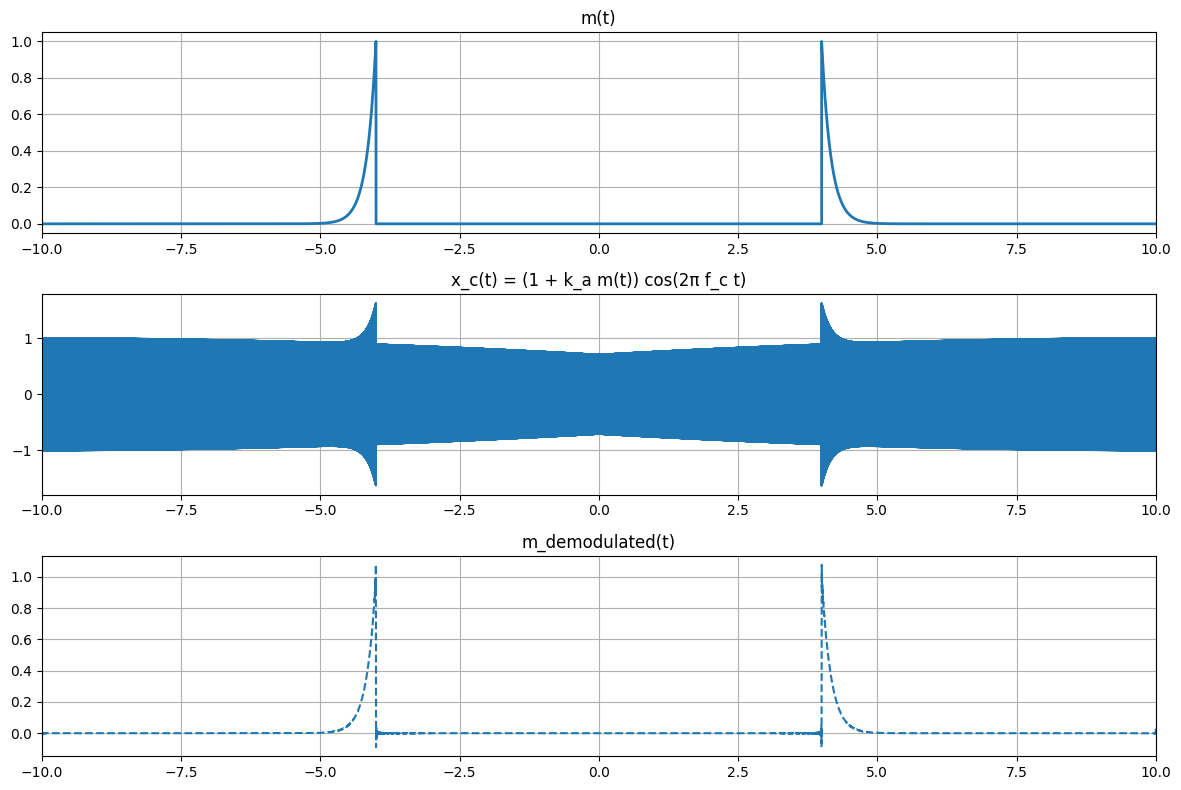

In [9]:
#  time vector
t = np.linspace(-10, 10, 400000)
dt = t[1] - t[0]
fs = 1 / dt

#  message signal
m1 = np.exp(-6*t) * ((t >= 4) & (t <= 8))
m2 = np.exp(6*t) * ((t >= -8) & (t <= -4))
m_t = m1 + m2

# normalize
pk = np.max(np.abs(m_t))
if pk > 0:
    m_t = m_t / pk

#  AM params
fc = 5000
ka = 0.83
B = 200

# modulated signal ( just like we created it in task 1.2)
carrier = np.cos(2 * np.pi * fc * t)
x_c = (1 + ka * m_t) * carrier

# cosine
y_mix = x_c * (2 * np.cos(2 * np.pi * fc * t))

# 7) lpf (just a rect in freq. domain)
Y = np.fft.fft(y_mix)
f = np.fft.fftfreq(len(t), d=dt)
fc_lpf = 1.2 * B
H = (np.abs(f) <= fc_lpf).astype(float)
y_lpf = np.real(np.fft.ifft(Y * H))

# 8) recovery ( demoulation )
m_demodulated = (y_lpf - 1) / ka

# 9) plot (m, x_c, m_demodulated)
m_demodulated = (y_lpf - 1) / ka

plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(t, m_t, linewidth=2)
plt.xlim(-10, 10)
plt.grid(True)
plt.title("m(t)")

plt.subplot(3, 1, 2)
plt.plot(t, x_c)
plt.xlim(-10, 10)
plt.grid(True)
plt.title("x_c(t) = (1 + k_a m(t)) cos(2π f_c t)")

plt.subplot(3, 1, 3)
plt.plot(t, m_demodulated, "--")
plt.xlim(-10, 10)
plt.grid(True)
plt.title("m_demodulated(t)")



plt.tight_layout()
plt.show()


the coherent detector was implemented exactly as the block diagram: a multiplier with a local oscillator, followed by an lpf.

the am signal is

$
x_c(t) = (1 + k_a m(t))\cos(2\pi f_c t)
$

### cosine

the received signal was multiplied by a synchronized carrier:

$
y_{mix}(t) = x_c(t)\,2\cos(2\pi f_c t)
$

using $2\cos^2(\theta)=1+\cos(2\theta)$:

$
y_{mix}(t) = (1+k_a m(t)) + (1+k_a m(t))\cos(4\pi f_c t)
$

so the mixer output contains:
- a baseband term: $1+k_a m(t)$
- a high-frequency term around $2f_c$

### LPF

an ideal rectangular low-pass filter was applied with cutoff slightly above the message bandwidth:

$
H(f)=
\begin{cases}
1 & |f|\le f_{c,lpf} \\
0 & \text{otherwise}
\end{cases}
\qquad
f_{c,lpf}\approx 1.2B
$

after filtering:

$
y_{lpf}(t) \approx 1 + k_a m(t)
$

### demodulation

dc removal and scaling give the demodulated message:

$
m_{demodulated}(t) = \frac{y_{lpf}(t)-1}{k_a}
$



during the implementation, the main adjustment was related to the time discretization.
initially, the number of samples in the time vector was too small compared to the carrier
frequency. this meant that the sampling frequency did not satisfy the nyquist condition
for the chosen \( f_c \).

as a result,the carrier component was not represented correctly in discrete time, and the
high-frequency terms created by the mixer could not be properly separated from the baseband
signal by the low-pass filter.

this was corrected by increasing the number of samples in the time vector, which increased
the sampling frequency so that \( f_s > 2 f_c \). after this adjustment, the coherent detector
behaved as expected: the low-pass filter removed the \( 2f_c \) term, and the recovered signal
matched the original message after dc removal and scaling.



## Task 1.6
Compare the output of these two methods together and with the original signal. Which of
these 2 demodulation methods perform more accurate?


### envelope detector

the envelope detector was able to follow the general shape of the message only around the
regions where the signal varies slowly. however, noticeable distortion appears between the
two exponential pulses and around the transitions. this behavior is expected because the
envelope detector relies on rectification and rc discharge, which introduces slope distortion
when the envelope changes faster than the rc time constant can track.

as seen in the plots, the recovered signal deviates from \( m(t) \) in amplitude and shape,
especially in the central region, and residual ripple remains due to the carrier component.

### coherent detector

the coherent detector output closely matches the original message signal over the entire time
interval. after multiplication with a synchronized carrier and low-pass filtering, the
baseband term \( 1 + k_a m(t) \) is cleanly separated from the high-frequency component at
\( 2f_c \). removing the dc term and scaling yields a signal that almost overlaps with
\( m(t) \).

the main requirement for this method is accurate carrier synchronization and a sufficiently
high sampling rate, both of which were satisfied in the final implementation.

### comparison and conclusion

comparing both outputs with the original signal shows that the coherent detector provides a
more accurate reconstruction of \( m(t) \). the envelope detector is simpler and does not
require carrier synchronization, but its performance is limited by rc selection and envelope
distortion. the coherent detector, while more complex, preserves both the amplitude and shape
of the message and therefore performs better in this setup.


## Task 1.7
Modulate the primary signal using the Upper Single Side Band (USSB) method and create time
and frequency domain plots. Then, demodulate the signal using the coherence demodulation
method and generate time and frequency domain plots for the demodulated signal.

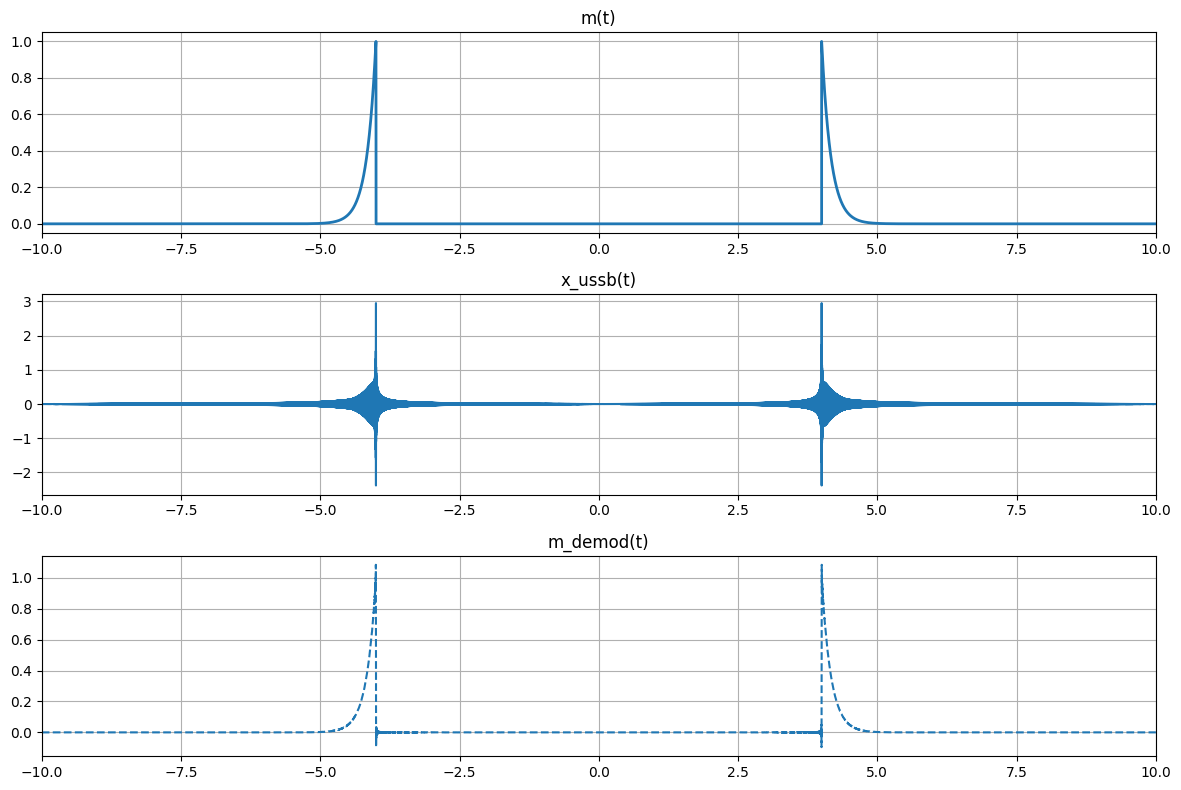

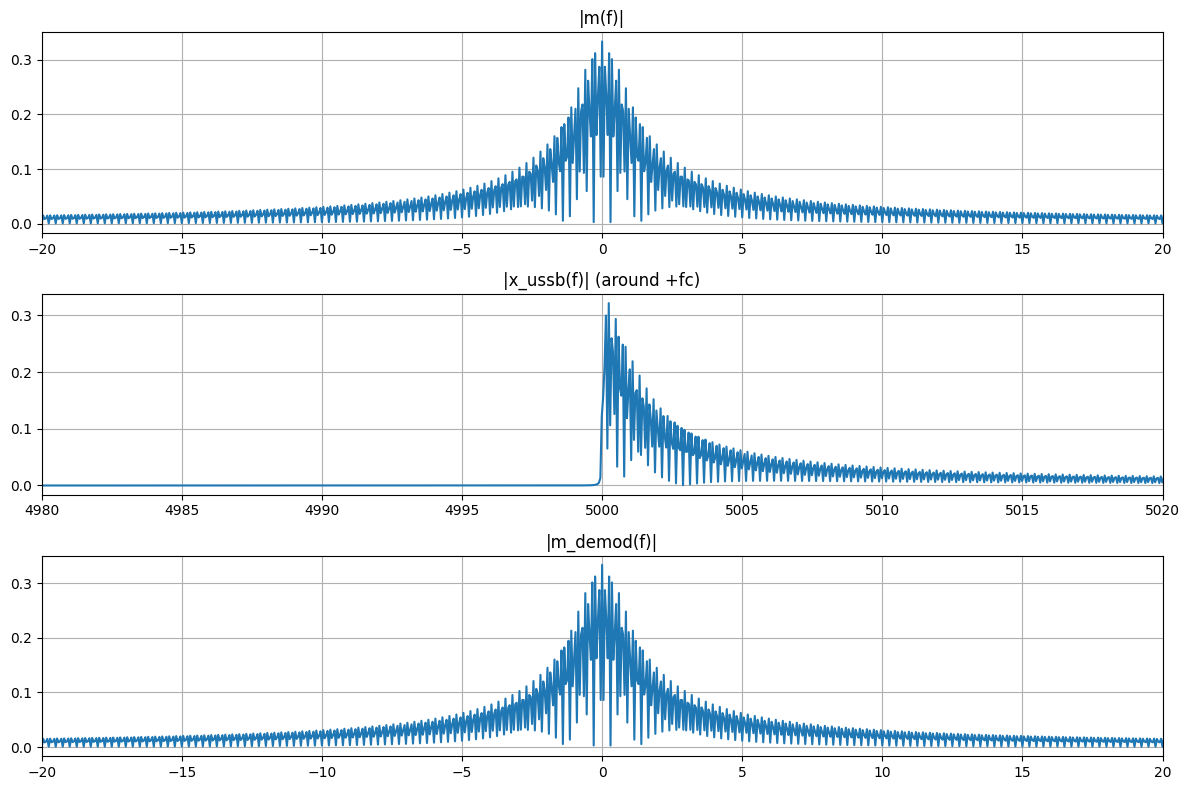

In [5]:
# time vector
t = np.linspace(-10, 10, 400000)
dt = t[1] - t[0]
fs = 1 / dt
n = len(t)

# primary (message) signal m(t)
m1 = np.exp(-6*t) * ((t >= 4) & (t <= 8))
m2 = np.exp(6*t) * ((t >= -8) & (t <= -4))
m_t = m1 + m2

# normalize
pk = np.max(np.abs(m_t))
if pk > 0:
    m_t = m_t / pk

# hilbert transform via analytic signal ( explained further in the markdown below )
M = np.fft.fft(m_t)

H = np.zeros(n)
if n % 2 == 0:
    H[0] = 1
    H[n//2] = 1
    H[1:n//2] = 2
else:
    H[0] = 1
    H[1:(n+1)//2] = 2

m_analytic = np.fft.ifft(M * H)
m_hat = np.imag(m_analytic)

# ussb parameters
fc = 5000
wc = 2 * np.pi * fc
Ac = 2.0
B = 200

# ussb modulation ( minus between two terms )
x_ussb = (Ac/2) * (m_t * np.cos(wc * t) - m_hat * np.sin(wc * t))

# coherent demod (same idea as task 1.5)
y_mix = x_ussb * (2 * np.cos(wc * t))

Y = np.fft.fft(y_mix)
f = np.fft.fftfreq(n, d=dt)

fc_lpf = 1.2 * B
lpf = (np.abs(f) <= fc_lpf).astype(float)

y_lpf = np.real(np.fft.ifft(Y * lpf))

# ssb recovery ( dem)
m_demod = (2 / Ac) * y_lpf

# spectra
def mag_spectrum(x):
    X = np.fft.fftshift(np.fft.fft(x)) * dt
    ff = np.fft.fftshift(np.fft.fftfreq(len(x), d=dt))
    return ff, np.abs(X)

# frequency domain
f_m, Mmag = mag_spectrum(m_t)
f_x, Xmag = mag_spectrum(x_ussb)
f_md, MDmag = mag_spectrum(m_demod)

# time domain plots
plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(t, m_t, linewidth=2)
plt.xlim(-10, 10)
plt.grid(True)
plt.title("m(t)")

plt.subplot(3, 1, 2)
plt.plot(t, x_ussb)
plt.xlim(-10, 10)
plt.grid(True)
plt.title("x_ussb(t)")

plt.subplot(3, 1, 3)
plt.plot(t, m_demod, "--")
plt.xlim(-10, 10)
plt.grid(True)
plt.title("m_demod(t)")

plt.tight_layout()
plt.show()

# frequency domain plots
plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(f_m, Mmag)
plt.xlim(-20, 20)
plt.grid(True)
plt.title("|m(f)|")

plt.subplot(3, 1, 2)
plt.plot(f_x, Xmag)
plt.xlim(fc - 20, fc + 20)
plt.grid(True)
plt.title("|x_ussb(f)| (around +fc)")

plt.subplot(3, 1, 3)
plt.plot(f_md, MDmag)
plt.xlim(-20, 20)
plt.grid(True)
plt.title("|m_demod(f)|")

plt.tight_layout()
plt.show()



for ussb, the hilbert transform $\hat m(t)$ was computed (using the analytic-signal fft method), then the modulated signal was formed as

$
x_{ussb}(t)=\frac{a_c}{2}\Bigl(m(t)\cos(\omega_c t)\;-\;\hat m(t)\sin(\omega_c t)\Bigr)
$

the minus sign enforces the upper single sideband construction.

time and frequency plots were generated for:
- $m(t)$ in time and $|m(f)|$
- $x_{ussb}(t)$ in time and $|x_{ussb}(f)|$ (zoomed around $+f_c$)
### hilbert transform
the hilbert transform was obtained using the analytic-signal fft method. the fourier transform of $m(t)$ was taken, negative frequencies were suppressed, and positive frequencies were doubled. after the inverse fft, the imaginary part of the analytic signal yielded $\hat m(t)$.

### cosine+LPF demodulation (same method as task 1.5)

the received ussb signal was mixed with a coherent carrier:

$
y_{mix}(t)=x_{ussb}(t)\cdot 2\cos(\omega_c t)
$

after mixing, an ideal lpf (rectangular mask in the fft domain) with cutoff $f_{lpf}=1.2b$ was applied to remove the high-frequency terms.

the remaining baseband term is approximately:

$
y_{lpf}(t)\approx \frac{a_c}{2}m(t)
$

so the recovered message was obtained by scaling:

$
m_{demod}(t)=\frac{2}{a_c}\,y_{lpf}(t)
$

time and frequency plots were generated for the demodulated signal to verify that $m_{demod}(t)$ matches the original $m(t)$.


## Task 1.8
Repeat the previous part for LSSB modulation.


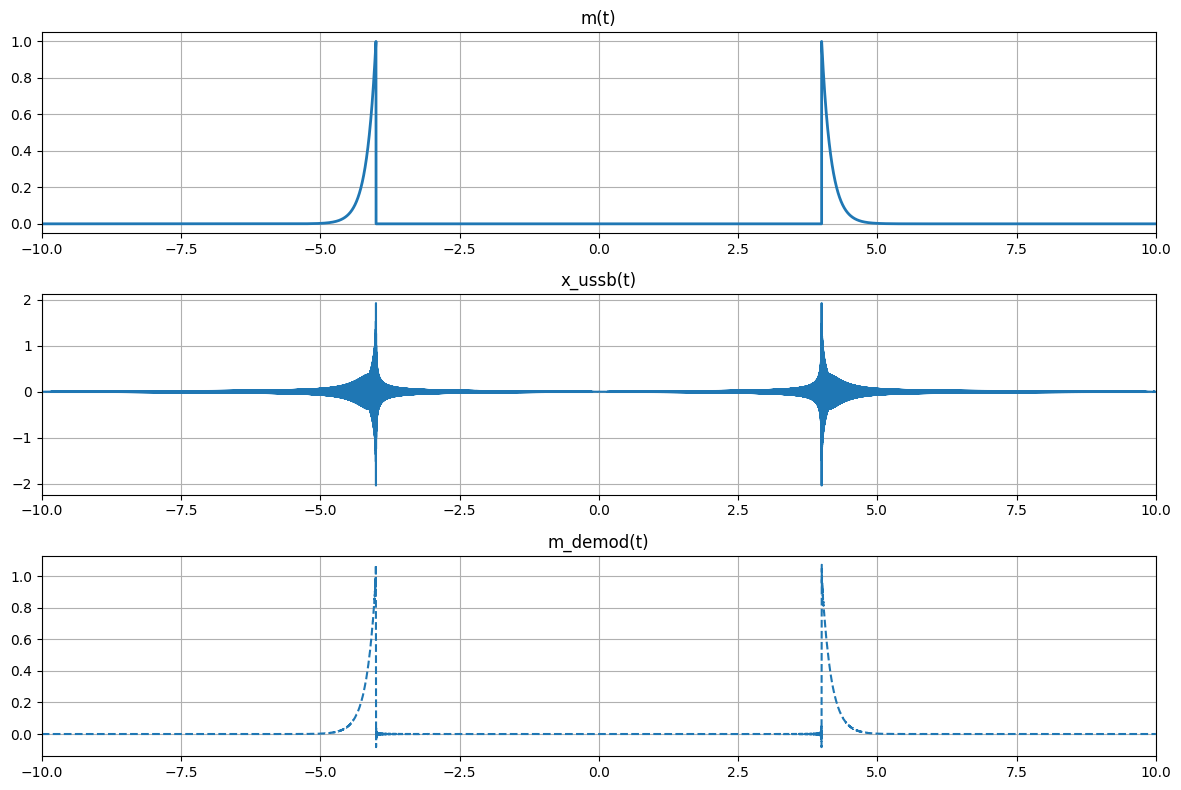

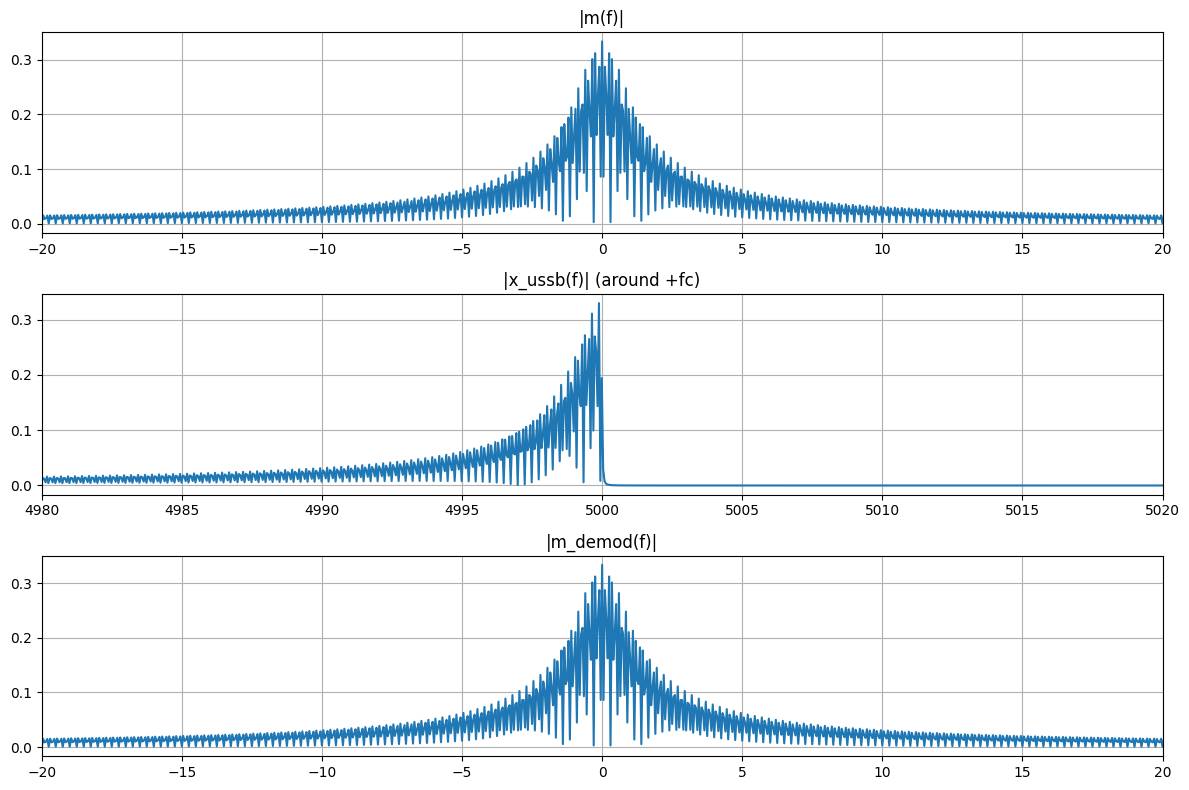

In [6]:
# same code as task 1.7 , we can just change minus to sign to addition when constructing the ssb modulated
# time vector
t = np.linspace(-10, 10, 400000)
dt = t[1] - t[0]
fs = 1 / dt
n = len(t)

# primary (message) signal m(t)
m1 = np.exp(-6 * t) * ((t >= 4) & (t <= 8))
m2 = np.exp(6 * t) * ((t >= -8) & (t <= -4))
m_t = m1 + m2

# normalize
pk = np.max(np.abs(m_t))
if pk > 0:
    m_t = m_t / pk

# hilbert transform via analytic signal ( explained further in the markdown below )
M = np.fft.fft(m_t)

H = np.zeros(n)
if n % 2 == 0:
    H[0] = 1
    H[n // 2] = 1
    H[1:n // 2] = 2
else:
    H[0] = 1
    H[1:(n + 1) // 2] = 2

m_analytic = np.fft.ifft(M * H)
m_hat = np.imag(m_analytic)

# ussb parameters
fc = 5000
wc = 2 * np.pi * fc
Ac = 2.0
B = 200

# ussb modulation ( addition between two terms instead of minus like task 1.7  )
x_ussb = (Ac / 2) * (m_t * np.cos(wc * t) + m_hat * np.sin(wc * t))

# coherent demod (same idea as task 1.5)
y_mix = x_ussb * (2 * np.cos(wc * t))

Y = np.fft.fft(y_mix)
f = np.fft.fftfreq(n, d=dt)

fc_lpf = 1.2 * B
lpf = (np.abs(f) <= fc_lpf).astype(float)

y_lpf = np.real(np.fft.ifft(Y * lpf))

# ssb recovery ( dem)
m_demod = (2 / Ac) * y_lpf


# spectra
def mag_spectrum(x):
    X = np.fft.fftshift(np.fft.fft(x)) * dt
    ff = np.fft.fftshift(np.fft.fftfreq(len(x), d=dt))
    return ff, np.abs(X)


# frequency domain
f_m, Mmag = mag_spectrum(m_t)
f_x, Xmag = mag_spectrum(x_ussb)
f_md, MDmag = mag_spectrum(m_demod)

# time domain plots
plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(t, m_t, linewidth=2)
plt.xlim(-10, 10)
plt.grid(True)
plt.title("m(t)")

plt.subplot(3, 1, 2)
plt.plot(t, x_ussb)
plt.xlim(-10, 10)
plt.grid(True)
plt.title("x_ussb(t)")

plt.subplot(3, 1, 3)
plt.plot(t, m_demod, "--")
plt.xlim(-10, 10)
plt.grid(True)
plt.title("m_demod(t)")

plt.tight_layout()
plt.show()

# frequency domain plots
plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(f_m, Mmag)
plt.xlim(-20, 20)
plt.grid(True)
plt.title("|m(f)|")

plt.subplot(3, 1, 2)
plt.plot(f_x, Xmag)
plt.xlim(fc - 20, fc + 20)
plt.grid(True)
plt.title("|x_ussb(f)| (around +fc)")

plt.subplot(3, 1, 3)
plt.plot(f_md, MDmag)
plt.xlim(-20, 20)
plt.grid(True)
plt.title("|m_demod(f)|")

plt.tight_layout()
plt.show()

## Task 1.9
Compare the original message with the AM, USSB, and LSSB output and explain the reason
for the difference. Also, compare the advantages and disadvantages of these three modulation
methods.

## task 1.9

the original message $m(t)$ is a low-frequency, time-limited baseband signal. all three modulation schemes used so far (am, ussb, and lssb) aim to translate this same information to a high-frequency band around the carrier, but they do so in fundamentally different ways, which explains the observed differences in both time and frequency domains.

### comparison with the original message

in **conventional am (dsb with carrier)**, the message appears twice in the spectrum: once in the upper sideband and once in the lower sideband, with an additional strong carrier component at $f_c$. after coherent demodulation, the recovered signal closely follows $m(t)$, but small distortions can be observed near sharp transitions. these are mainly due to filtering limits and the presence of unnecessary spectral components that must be removed.

in **ussb**, only the upper sideband is transmitted. the demodulated signal matches the original message very accurately, because the entire information content of $m(t)$ is preserved in a single sideband without spectral redundancy. the absence of the carrier and the opposite sideband reduces interference and simplifies the baseband recovery after coherent mixing and low-pass filtering.

in **lssb**, the situation is symmetric to ussb, but with the lower sideband retained instead. the demodulated output is again a faithful reconstruction of $m(t)$, and any difference from ussb is purely spectral (which side of the carrier is used), not informational. in time domain, the recovered signal is essentially identical to the original message.

### reasons for the differences

the differences observed between the three outputs are not due to loss of information in ssb, but to **how efficiently the spectrum is used**. am spreads the message over two sidebands and adds a carrier that carries no information, while ssb concentrates all the information into a single sideband. this concentration reduces bandwidth and improves noise performance, which is why ussb and lssb show cleaner recovery in the simulations.

### advantages and disadvantages

**am (dsb with carrier)**
- advantages:
  - simple to generate and demodulate
  - envelope detection possible (no carrier synchronization needed)
- disadvantages:
  - poor power efficiency (most power in the carrier)
  - double bandwidth usage
  - more sensitive to noise and distortion

**ussb / lssb**
- advantages:
  - half the bandwidth of am
  - significantly better power efficiency
  - improved noise performance
- disadvantages:
  - more complex transmitter and receiver
  - requires accurate carrier synchronization for demodulation
  - implementation relies on hilbert transform or sharp filtering

overall, the simulations confirm that while am is attractive for simplicity, ssb (both ussb and lssb) is clearly superior in terms of spectral and power efficiency, producing a demodulated signal that more closely matches the original message under the same conditions.


## Task 1.10 (Bonus)
Use a microphone to record your voice. Then, apply the AM modulation method
that you used in the second part of this question to your speech signal and plot the spectrum
of the modulated signal. Next, use the two demodulation methods that you studied in the
question to recover your speech signal and compare the outputs

In [10]:
# part1 , record and save :
fs = 15990
duration = 9
save_path= r"C:\Users\Asus\OneDrive\Desktop\EE Archive\5th_semester\CommunicationSystems\CHW_2\fig1.png"


print("recording...")
x = sd.rec(int(duration * fs), samplerate=fs, channels=1, dtype="float32")
sd.wait()
print("done")

x = x.flatten()
write(save_path, fs, x)

print(f"saved: {save_path}")


recording...
done
saved: C:\Users\Asus\OneDrive\Desktop\EE Archive\5th_semester\CommunicationSystems\CHW_2\fig1.png


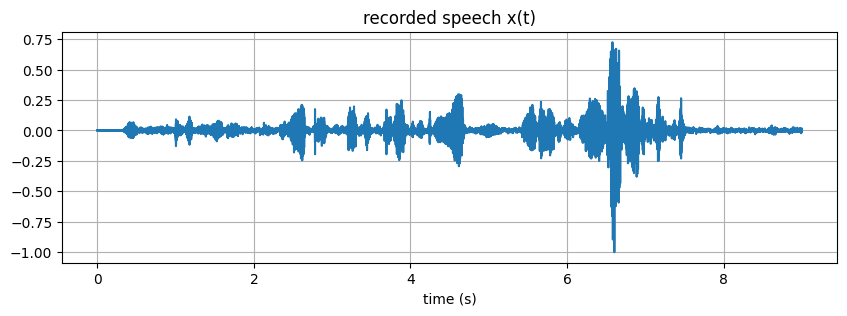

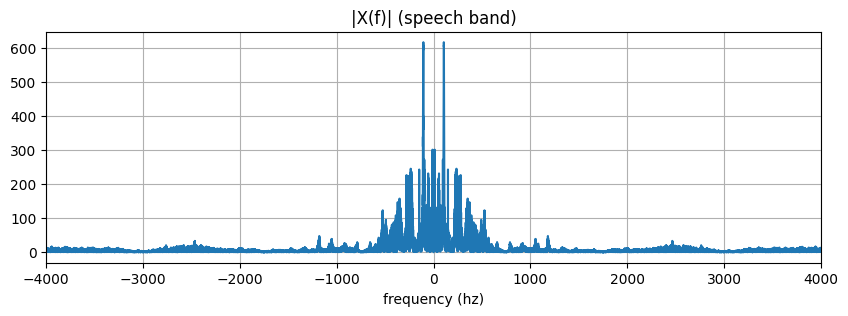

In [11]:
#part2 , plot and playing the aduio that was just recorded
load_path =  r"C:\Users\Asus\OneDrive\Desktop\EE Archive\5th_semester\CommunicationSystems\CHW_2\fig1.png"

fs, x = read(load_path)

if x.dtype != np.float32:
    x = x.astype(np.float32)
    x = x / np.max(np.abs(x))

x = x - np.mean(x)
x = x / np.max(np.abs(x))

t = np.arange(len(x)) / fs

plt.figure(figsize=(10, 3))
plt.plot(t, x)
plt.xlabel("time (s)")
plt.title("recorded speech x(t)")
plt.grid(True)
plt.show()

X = np.fft.fftshift(np.fft.fft(x))
f = np.fft.fftshift(np.fft.fftfreq(len(x), d=1/fs))

plt.figure(figsize=(10, 3))
plt.plot(f, np.abs(X))
plt.xlim(-4000, 4000)
plt.xlabel("frequency (hz)")
plt.title("|X(f)| (speech band)")
plt.grid(True)
plt.show()

Audio(x, rate=fs)



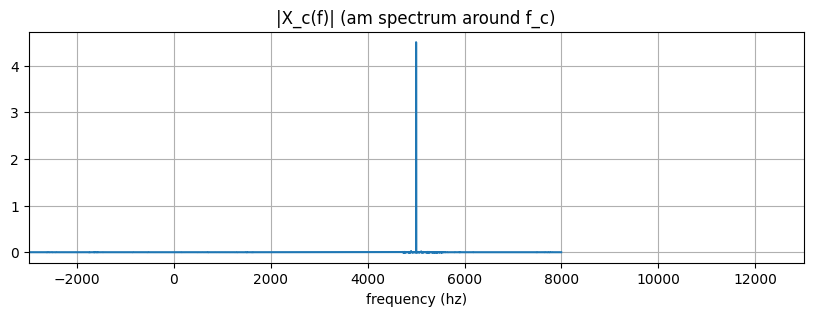

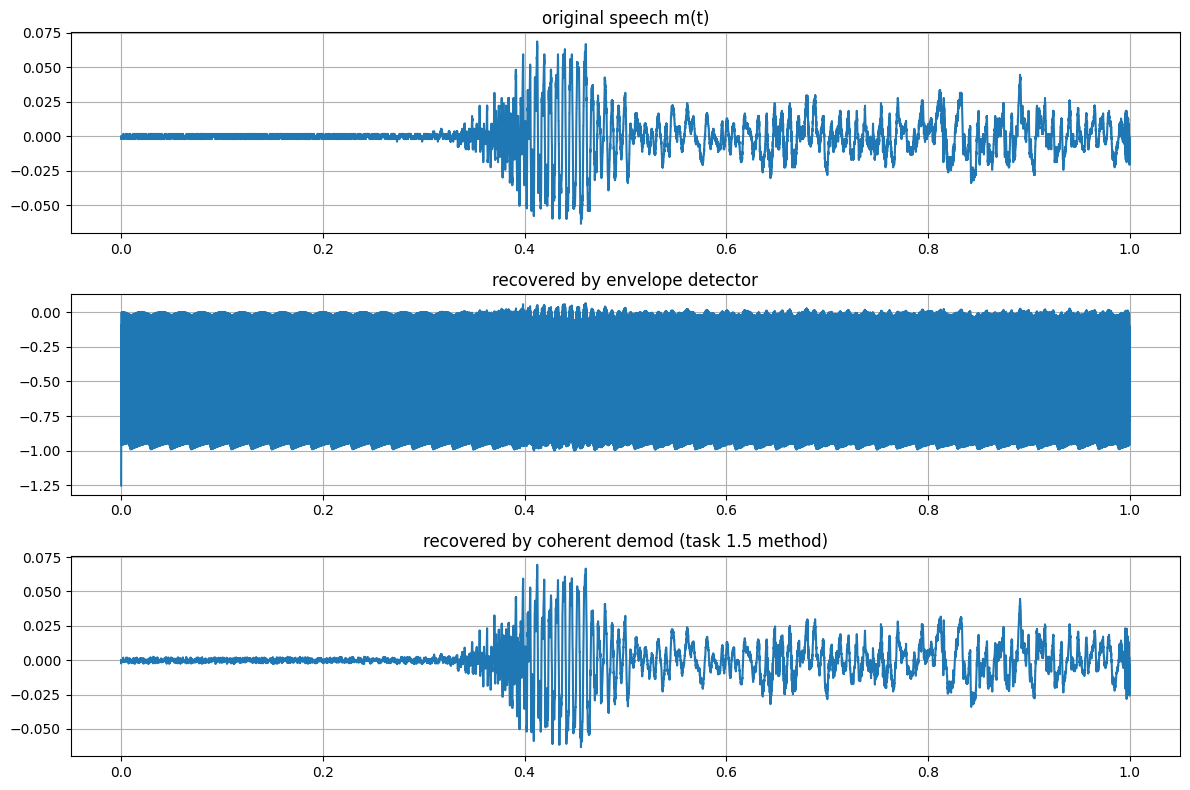

original


envelope detector output


coherent demod output


saved:
C:\Users\Asus\OneDrive\Desktop\EE Archive\5th_semester\CommunicationSystems\CHW_2\speech_original.wav
C:\Users\Asus\OneDrive\Desktop\EE Archive\5th_semester\CommunicationSystems\CHW_2\speech_env.wav
C:\Users\Asus\OneDrive\Desktop\EE Archive\5th_semester\CommunicationSystems\CHW_2\speech_coherent.wav


In [15]:
#part3 , modulating and demoulating

import numpy as np
import matplotlib.pyplot as plt
from scipy.io.wavfile import read
from IPython.display import Audio

# load speech
load_path = r"C:\Users\Asus\OneDrive\Desktop\EE Archive\5th_semester\CommunicationSystems\CHW_2\fig1.png"

fs, m = read(load_path)

m = m.astype(np.float32).flatten()
m = m - np.mean(m)
m = m / np.max(np.abs(m))

t = np.arange(len(m)) / fs
dt = 1 / fs

# am paramteres
ka = 0.8
fc = 5000
B = 3500                   # speech bandwidth ( usual )

carrier = np.cos(2 * np.pi * fc * t)
x_c = (1 + ka * m) * carrier

#  spectrum of modulated signal
Xc = np.fft.fftshift(np.fft.fft(x_c)) * dt
f = np.fft.fftshift(np.fft.fftfreq(len(x_c), d=dt))

plt.figure(figsize=(10, 3))
plt.plot(f, np.abs(Xc))
plt.xlim(fc - 8000, fc + 8000)
plt.xlabel("frequency (hz)")
plt.title("|X_c(f)| (am spectrum around f_c)")
plt.grid(True)
plt.show()

# envelope detector (same algorithm as earlier )
def envelope_detector(x, t, rc, y0):
    x = np.asarray(x)
    t = np.asarray(t)
    dt = t[1] - t[0]

    xr = np.abs(x)

    y = np.zeros_like(xr)
    y[0] = y0

    a = np.exp(-dt / rc)

    for n in range(1, len(xr)):
        yd = y[n - 1] * a
        y[n] = max(xr[n], yd)

    return y

# pick rc using B (same idea as before)
rc = 1 / (2 * np.pi * B)
env = envelope_detector(x_c, t, rc=rc, y0=0.0)
m_env = (env - 1) / ka

# coherent demod (same method as task 1.5)
y_mix = x_c * (2 * np.cos(2 * np.pi * fc * t))

Y = np.fft.fft(y_mix)
ff = np.fft.fftfreq(len(y_mix), d=dt)

fc_lpf = 1.2 * B
H = (np.abs(ff) <= fc_lpf).astype(float)

y_lpf = np.real(np.fft.ifft(Y * H))
m_coh = (y_lpf - 1) / ka

# time domain comparison
Tzoom = 1.0
nz = int(Tzoom * fs)

plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(t[:nz], m[:nz], linewidth=1.5)
plt.grid(True)
plt.title("original speech m(t)")

plt.subplot(3, 1, 2)
plt.plot(t[:nz], m_env[:nz])
plt.grid(True)
plt.title("recovered by envelope detector")

plt.subplot(3, 1, 3)
plt.plot(t[:nz], m_coh[:nz])
plt.grid(True)
plt.title("recovered by coherent demod (task 1.5 method)")

plt.tight_layout()
plt.show()

# listening
print("original")
display(Audio(m, rate=fs))

print("envelope detector output")
display(Audio(m_env, rate=fs))

print("coherent demod output")
display(Audio(m_coh, rate=fs))

from scipy.io.wavfile import write
import os

base_path = r"C:\Users\Asus\OneDrive\Desktop\EE Archive\5th_semester\CommunicationSystems\CHW_2"
os.makedirs(base_path, exist_ok=True)

def save_wav(path, fs, x):
    x = np.asarray(x, dtype=np.float32)
    x = x / (np.max(np.abs(x)) + 1e-12)          # normalize
    x_i16 = (x * 32767).astype(np.int16)         # wav int16
    write(path, fs, x_i16)

save_wav(os.path.join(base_path, "speech_original.wav"), fs, m)
save_wav(os.path.join(base_path, "speech_env.wav"), fs, m_env)
save_wav(os.path.join(base_path, "speech_coherent.wav"), fs, m_coh)

print("saved:")
print(os.path.join(base_path, "speech_original.wav"))
print(os.path.join(base_path, "speech_env.wav"))
print(os.path.join(base_path, "speech_coherent.wav"))



# Question 2: Frequency Modulation
In this section, we want to obtain the sent message from its FM modulated signal with three
methods. We call the sent message $m(t)$ and we have:

$m(t) = \sin(25\pi t), \quad 0 \le t \le 1$          


## Task 2.1
Sample this message at $fs$ = 10 kHz and obtain the FM signal with the following values.

$
x_c(t) = A_c \cos\!\left( 2\pi f_c t + 2\pi f_{\Delta} \int_{0}^{t} m(\tau)\, d\tau \right)
\quad
$
$
(A_c = 1,\; f_c = 200~\text{Hz},\; f_{\Delta} = 30~\text{Hz/V})
$


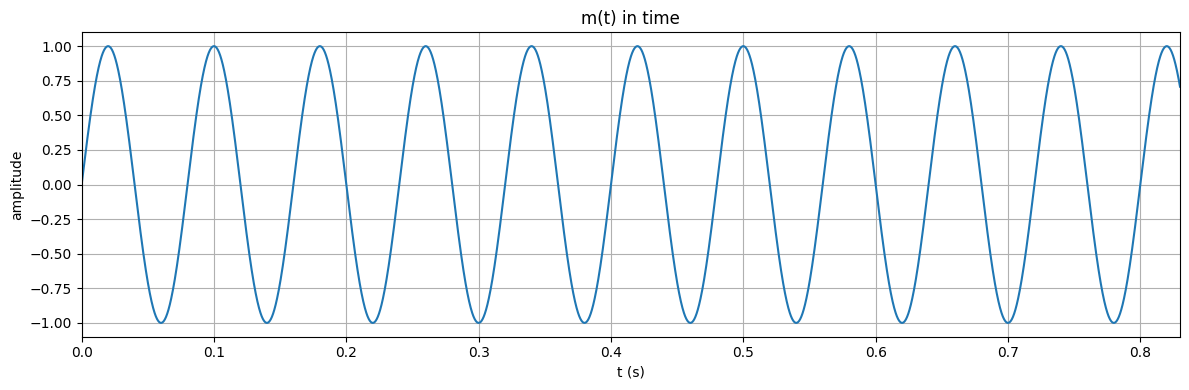

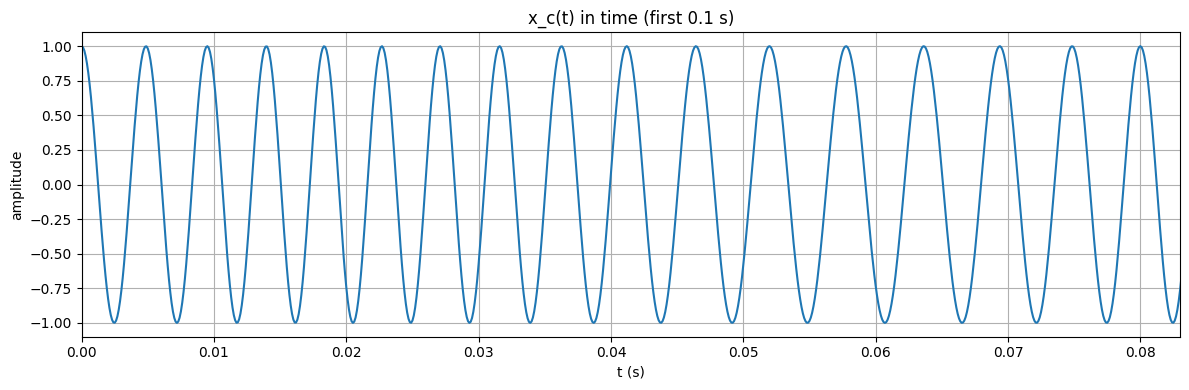

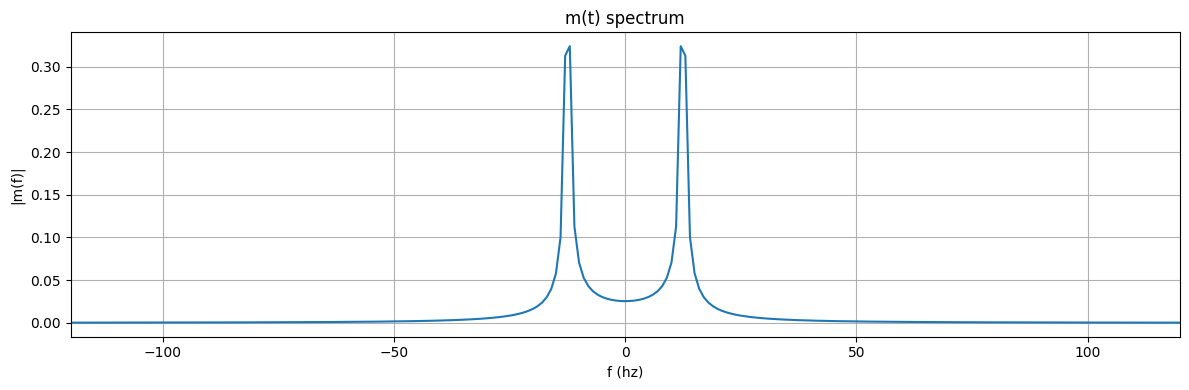

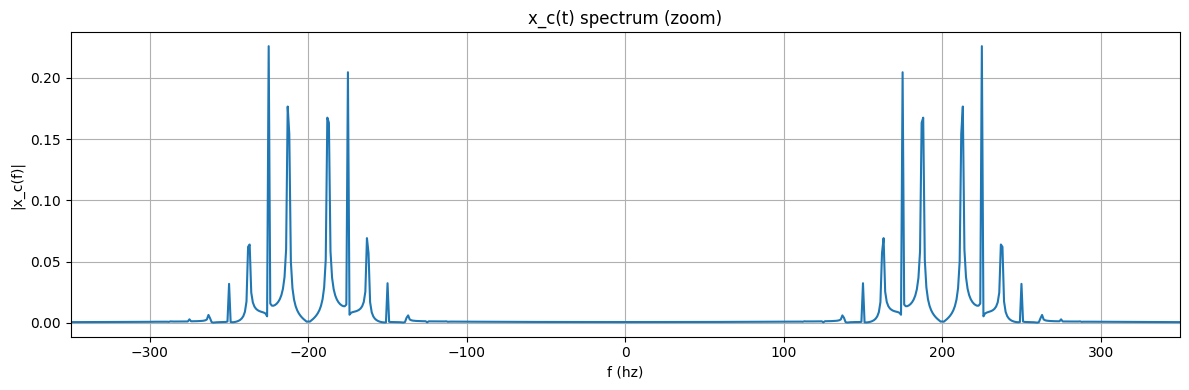

In [18]:
# parameters
fs = 10_000
Ac = 1.0
fc = 200.0
fD = 30.0

# time vector
dt = 1 / fs
t = np.arange(0, 1 + dt, dt)

# message signal itself
m = np.sin(25 * np.pi * t)

# defining the integral
m_int = np.cumsum(m) * dt

# fm
phi = 2 * np.pi * fc * t + 2 * np.pi * fD * m_int
xc = Ac * np.cos(phi)


# defining spectrum helper
def spectrum(x, fs):
    n = len(x)
    X = np.fft.fftshift(np.fft.fft(x)) / n
    f = np.fft.fftshift(np.fft.fftfreq(n, d=1 / fs))
    return f, np.abs(X)


# spectra
f_m, M = spectrum(m, fs)
f_x, X = spectrum(xc, fs)

# time plots
plt.figure(figsize=(12, 4))
plt.plot(t, m)
plt.xlim(0, 0.83)
plt.grid(True)
plt.title("m(t) in time")
plt.xlabel("t (s)")
plt.ylabel("amplitude")
plt.tight_layout()

plt.figure(figsize=(12, 4))
plt.plot(t, xc)
plt.xlim(0, 0.083)
plt.grid(True)
plt.title("x_c(t) in time (first 0.1 s)")
plt.xlabel("t (s)")
plt.ylabel("amplitude")
plt.tight_layout()

# spectrum plots
plt.figure(figsize=(12, 4))
plt.plot(f_m, M)
plt.xlim(-120, 120)
plt.grid(True)
plt.title("m(t) spectrum")
plt.xlabel("f (hz)")
plt.ylabel("|m(f)|")
plt.tight_layout()

plt.figure(figsize=(12, 4))
plt.plot(f_x, X)
plt.xlim(-350, 350)
plt.grid(True)
plt.title("x_c(t) spectrum (zoom)")
plt.xlabel("f (hz)")
plt.ylabel("|x_c(f)|")
plt.tight_layout()

plt.show()

given

$
m(t) = \sin(25\pi t), \quad 0 \le t \le 1
$

was sampled with

$
f_s = 10\,\text{khz}, \quad t[n] = \frac{n}{f_s}, \quad 0 \le n \le f_s
$

so the discrete-time message became

$
m[n] = \sin(25\pi t[n])
$

the fm signal was generated from

$
x_c(t) = A_c \cos\!\left( 2\pi f_c t + 2\pi f_{\Delta} \int_{0}^{t} m(\tau)\, d\tau \right)
$

with

$
A_c = 1,\quad f_c = 200~\text{hz},\quad f_{\Delta} = 30~\text{hz/v}
$

to implement the integral numerically, the cumulative sum approximation was used:

$
\int_{0}^{t[n]} m(\tau)\, d\tau \approx \sum_{k=0}^{n} m[k]\Delta t,
\quad \Delta t = \frac{1}{f_s}
$

then the instantaneous phase was computed as

$
\phi[n] = 2\pi f_c t[n] + 2\pi f_{\Delta}\!\left(\sum_{k=0}^{n} m[k]\Delta t\right)
$

and the fm waveform as

$
x_c[n] = A_c \cos(\phi[n])
$

the required plots were produced:
- time domain: $m(t)$ over $0$ to $1$ s, and $x_c(t)$ (shown over the first $0.1$ s for clarity)
- frequency domain: fft-based magnitude spectra for both $m(t)$ and $x_c(t)$ (with a zoomed frequency axis for readability)


## Task 2.2
With the help of _scipy.signal.detrend_ and _scipy.signal.hilbert_ command, restore the
message signal ideally.

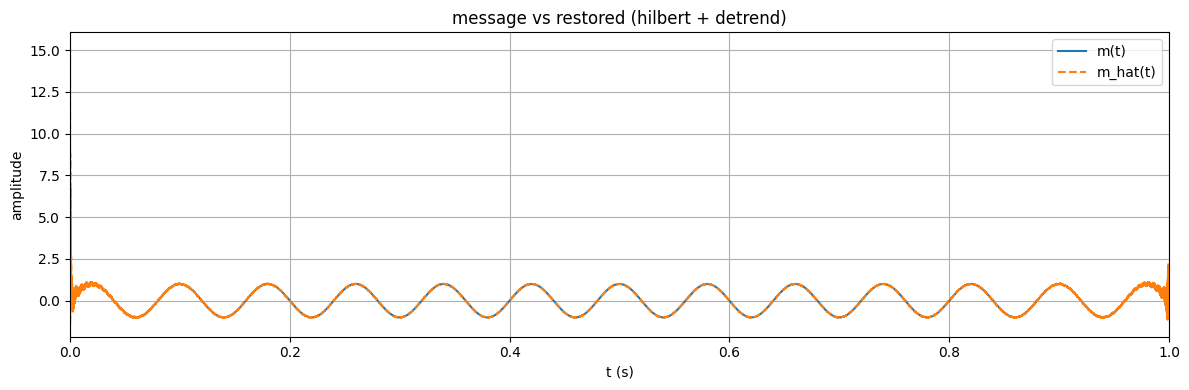

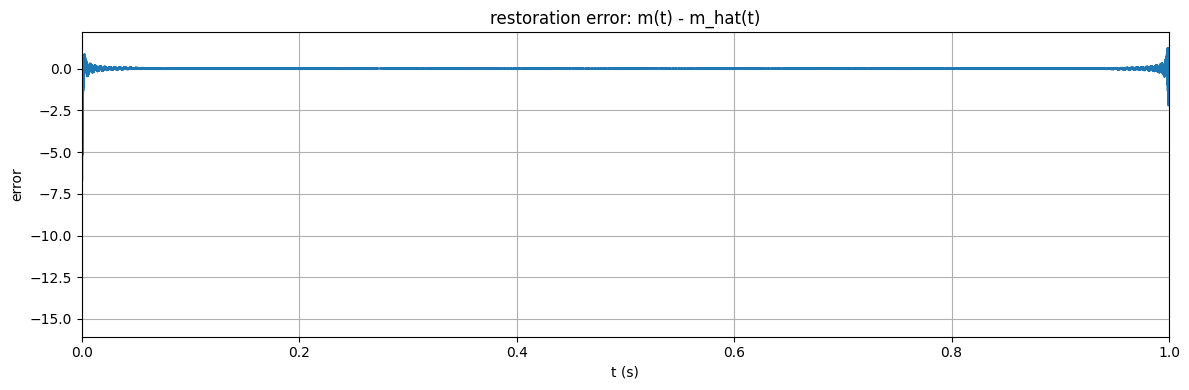

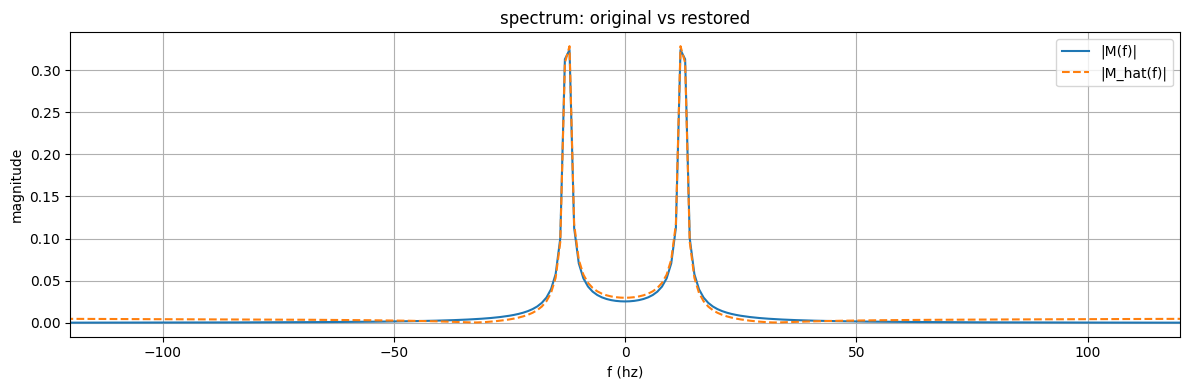

In [20]:
from scipy.signal import hilbert, detrend
# parameters
fs = 10_000
Ac = 1.0
fc = 200.0
fD = 30.0

# time
dt = 1 / fs
t = np.arange(0, 1 + dt, dt)

# message
m = np.sin(25 * np.pi * t)

# integral
m_int = np.cumsum(m) * dt

# fm
phi = 2 * np.pi * fc * t + 2 * np.pi * fD * m_int
xc = Ac * np.cos(phi)

# analytic
z = hilbert(xc)

# phase
ph = np.unwrap(np.angle(z))

# detrend
ph_d = detrend(ph)

# diff
dph = np.diff(ph_d)

# recover
m_hat = np.r_[dph / (2 * np.pi * fD * dt), dph[-1] / (2 * np.pi * fD * dt)]


# spectrum helper
def spectrum(x, fs):
    n = len(x)
    X = np.fft.fftshift(np.fft.fft(x)) / n
    f = np.fft.fftshift(np.fft.fftfreq(n, d=1 / fs))
    return f, np.abs(X)


# spectra
f_m, M = spectrum(m, fs)
f_h, H = spectrum(m_hat, fs)

# time plot
plt.figure(figsize=(12, 4))
plt.plot(t, m, label="m(t)")
plt.plot(t, m_hat, "--", label="m_hat(t)")
plt.xlim(0, 1)
plt.grid(True)
plt.title("message vs restored (hilbert + detrend)")
plt.xlabel("t (s)")
plt.ylabel("amplitude")
plt.legend()
plt.tight_layout()

# error
plt.figure(figsize=(12, 4))
plt.plot(t, m - m_hat)
plt.xlim(0, 1)
plt.grid(True)
plt.title("restoration error: m(t) - m_hat(t)")
plt.xlabel("t (s)")
plt.ylabel("error")
plt.tight_layout()

# spectrum plot
plt.figure(figsize=(12, 4))
plt.plot(f_m, M, label="|M(f)|")
plt.plot(f_h, H, "--", label="|M_hat(f)|")
plt.xlim(-120, 120)
plt.grid(True)
plt.title("spectrum: original vs restored")
plt.xlabel("f (hz)")
plt.ylabel("magnitude")
plt.legend()
plt.tight_layout()

plt.show()


given the fm signal

$
x_c(t) = A_c \cos\!\left( 2\pi f_c t + 2\pi f_{\Delta} \int_{0}^{t} m(\tau)\, d\tau \right)
$

define the total phase

$
\phi(t) = 2\pi f_c t + 2\pi f_{\Delta} \int_{0}^{t} m(\tau)\, d\tau
$

differentiate:

$
\frac{d\phi(t)}{dt} = 2\pi f_c + 2\pi f_{\Delta} m(t)
$

so the message is

$
m(t) = \frac{1}{2\pi f_{\Delta}}\frac{d\phi(t)}{dt} - \frac{f_c}{f_{\Delta}}
$

to extract $\phi(t)$ from the real fm waveform, the analytic signal was formed using hilbert:

$
z(t) = x_c(t) + j\,\hat{x}_c(t)
$

then the instantaneous phase was obtained by

$
\phi(t) = \mathrm{unwrap}\bigl(\angle z(t)\bigr)
$

instead of explicitly subtracting the carrier term, `scipy.signal.detrend` was applied to the unwrapped phase to remove the dominant linear component (the $2\pi f_c t$ term). after detrending,

$
\phi_d(t) \approx 2\pi f_{\Delta} \int_{0}^{t} m(\tau)\, d\tau
$

then

$
m(t) \approx \frac{1}{2\pi f_{\Delta}} \frac{d\phi_d(t)}{dt}
$

in discrete time (with $\Delta t = 1/f_s$), the derivative was implemented by a first difference:

$
m[n] \approx \frac{1}{2\pi f_{\Delta}} \cdot \frac{\phi_d[n]-\phi_d[n-1]}{\Delta t}
$

finally, the time plot compares $m(t)$ and the restored $\hat m(t)$, and the spectrum plot compares $|M(f)|$ and $|\hat M(f)|$ to verify ideal recovery.


## Task 2.3
Taking the derivative of the signal $x_c(t)$ we will have:
$
x_d(t) = \frac{d x_c(t)}{d t} = -A_c \bigl(2\pi f_c + 2\pi f_{\Delta} m(t)\bigr)
\sin\!\left( 2\pi f_c t + 2\pi f_{\Delta} \int_{0}^{t} m(\tau)\, d\tau \right)
$
If the frequency changes $\sin\!\left( 2\pi f_c t + 2\pi f_{\Delta} \int_{0}^{t} m(\tau)\, d\tau \right)$ of the signal due to the message $m(t)$ are ignored compared to the frequency $f_c$, we can consider the $x_d$ signal as an AM signal whose envelope contains the desired message. Restore the message using the Envelope Detector made in the first problem with new values for the resistor and capacitor.


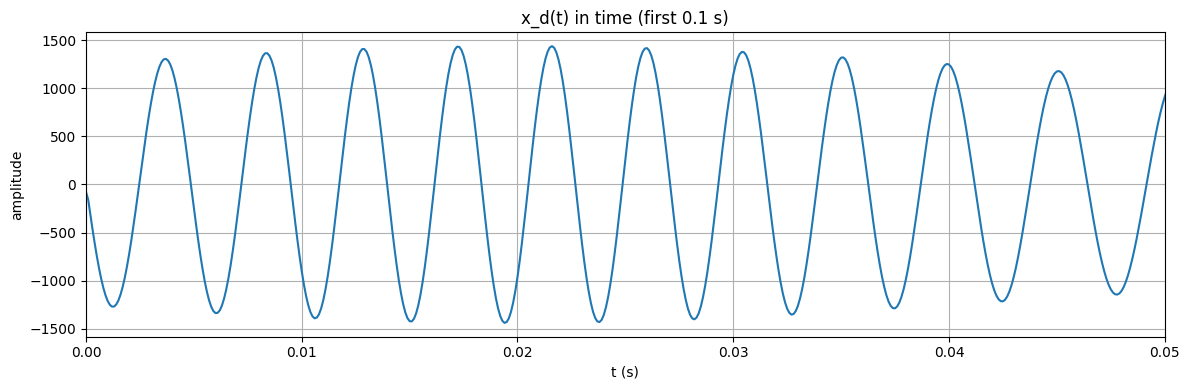

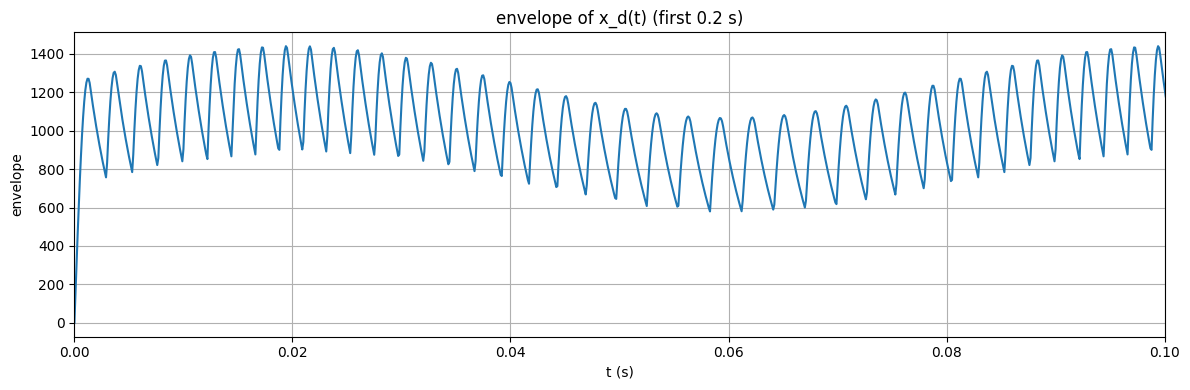

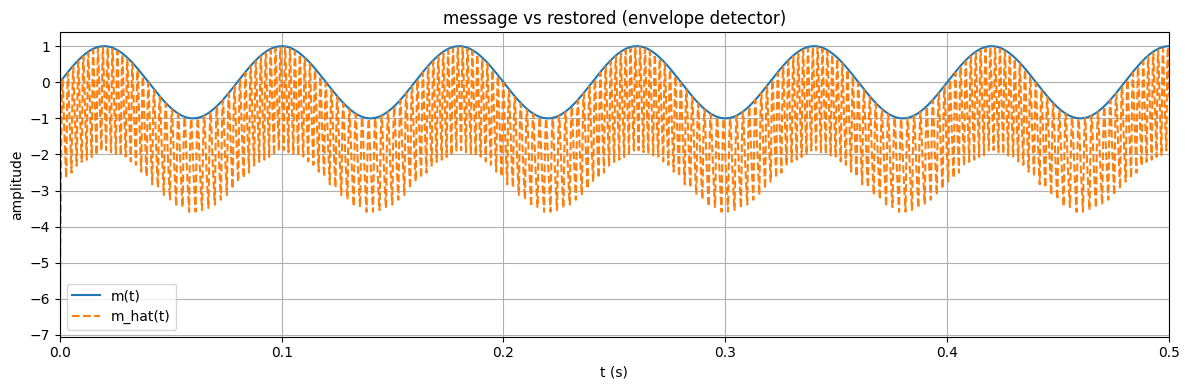

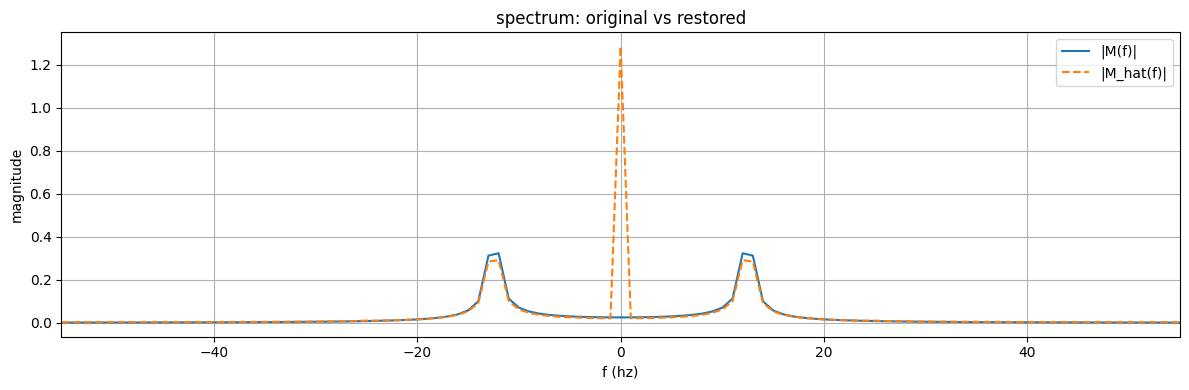

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# params
fs = 10_000
Ac = 1.0
fc = 200.0
fD = 30.0

# time
dt = 1 / fs
t = np.arange(0, 1 + dt, dt)

# message
m = np.sin(25 * np.pi * t)

# integral
m_int = np.cumsum(m) * dt

# fm
phi = 2 * np.pi * fc * t + 2 * np.pi * fD * m_int
xc = Ac * np.cos(phi)

# derivative
xd = np.gradient(xc, dt)


# envelope detector
def envelope_detector(x, t, rc, y0):
    x = np.asarray(x)
    t = np.asarray(t)
    dt = t[1] - t[0]

    xr = np.abs(x)

    y = np.zeros_like(xr)
    y[0] = y0

    a = np.exp(-dt / rc)

    for n in range(1, len(xr)):
        yd = y[n - 1] * a
        y[n] = max(xr[n], yd)

    return y


# rc choice
R = 1_000.0
C = 3e-6
RC = R * C

# detect envelope
env = envelope_detector(xd, t, RC, y0=0.0)

# recover message
m_hat = (env / (Ac * 2 * np.pi) - fc) / fD


# spectrum helper
def spectrum(x, fs):
    n = len(x)
    X = np.fft.fftshift(np.fft.fft(x)) / n
    f = np.fft.fftshift(np.fft.fftfreq(n, d=1 / fs))
    return f, np.abs(X)


# spectra
f_m, M = spectrum(m, fs)
f_h, H = spectrum(m_hat, fs)

# time plots
plt.figure(figsize=(12, 4))
plt.plot(t, xd)
plt.xlim(0, 0.05)
plt.grid(True)
plt.title("x_d(t) in time (first 0.05 s)")
plt.xlabel("t (s)")
plt.ylabel("amplitude")
plt.tight_layout()

plt.figure(figsize=(12, 4))
plt.plot(t, env)
plt.xlim(0, 0.1)
plt.grid(True)
plt.title("envelope of x_d(t) (first 0.1 s)")
plt.xlabel("t (s)")
plt.ylabel("envelope")
plt.tight_layout()

plt.figure(figsize=(12, 4))
plt.plot(t, m, label="m(t)")
plt.plot(t, m_hat, "--", label="m_hat(t)")
plt.xlim(0, 0.5)
plt.grid(True)
plt.title("message vs restored (envelope detector)")
plt.xlabel("t (s)")
plt.ylabel("amplitude")
plt.legend()
plt.tight_layout()

# spectrum plot
plt.figure(figsize=(12, 4))
plt.plot(f_m, M, label="|M(f)|")
plt.plot(f_h, H, "--", label="|M_hat(f)|")
plt.xlim(-55, 55)
plt.grid(True)
plt.title("spectrum: original vs restored")
plt.xlabel("f (hz)")
plt.ylabel("magnitude")
plt.legend()
plt.tight_layout()

plt.show()


given

$
x_c(t) = A_c \cos\!\left( 2\pi f_c t + 2\pi f_{\Delta} \int_{0}^{t} m(\tau)\, d\tau \right)
$

differentiate:

$
x_d(t)=\frac{d x_c(t)}{dt}
=
-A_c \bigl(2\pi f_c + 2\pi f_{\Delta} m(t)\bigr)
\sin\!\left( 2\pi f_c t + 2\pi f_{\Delta} \int_{0}^{t} m(\tau)\, d\tau \right)
$

if the phase/frequency variation inside the sine term is ignored compared to the carrier, then

$
x_d(t) \approx -A_c \bigl(2\pi f_c + 2\pi f_{\Delta} m(t)\bigr)\sin(2\pi f_c t)
$

so $x_d(t)$ behaves like an am signal whose envelope is

$
e(t) \approx A_c \bigl(2\pi f_c + 2\pi f_{\Delta} m(t)\bigr)
$

therefore

$
m(t) \approx \frac{1}{f_{\Delta}}\left(\frac{e(t)}{A_c 2\pi} - f_c\right)
$

### envelope detector rc choice

the envelope detector must satisfy the usual condition:

$
\frac{1}{2\pi f_c} \ll rc \ll \frac{1}{2\pi f_m^{\max}}
$

here

$
f_c = 200~\text{hz}, \quad m(t)=\sin(25\pi t)=\sin(2\pi\cdot 12.5\, t)\Rightarrow f_m^{\max}=12.5~\text{hz}
$

so

$
\frac{1}{2\pi f_c}\approx 0.00080~\text{s},\quad
\frac{1}{2\pi f_m^{\max}}\approx 0.0127~\text{s}
$

was chosen

$
rc = 0.003~\text{s}
$

(using $r=1~\text{k}\Omega$ and $c=3~\mu\text{f}$), which lies between these two limits, so the capacitor discharges slowly within a carrier cycle, but fast enough to follow the message envelope.

the plots show:
- $x_d(t)$ (time) and its detected envelope (time)
- $m(t)$ vs $\hat m(t)$ in time
- spectra of $m(t)$ and $\hat m(t)$ for verification


## Task 2.4
We can also extract the message from the FM signal by using a Zero Crossing Detector.
This method is based on the fact that the message value influences the instantaneous frequency
of the FM signal. When the message value is high, the instantaneous frequency is also high, and
when the message value is low, the instantaneous frequency is low. Therefore, we can estimate
the frequency of the signal by counting the number of times it crosses zero. A high frequency
signal will have more zero crossings than a low frequency signal. The block diagram in the following figure shows how we can use a Zero Crossing Detector to reveal the message from the FM signal.

![fig3:Zero Crossing Detector](fig3.png)

A Zero Crossing Detector block can be implemented by taking the derivative of the signal
$sign(xc(t))$ and then finding the absolute value of the result. This will give us the locations where the signal crossed zero. The output of this block should be one only when a zero crossing occurs and zero otherwise. A Pulse Generator block can then produce a rectangular pulse for a short duration for each zero crossing. This way, we can recover the message from the FM signal.

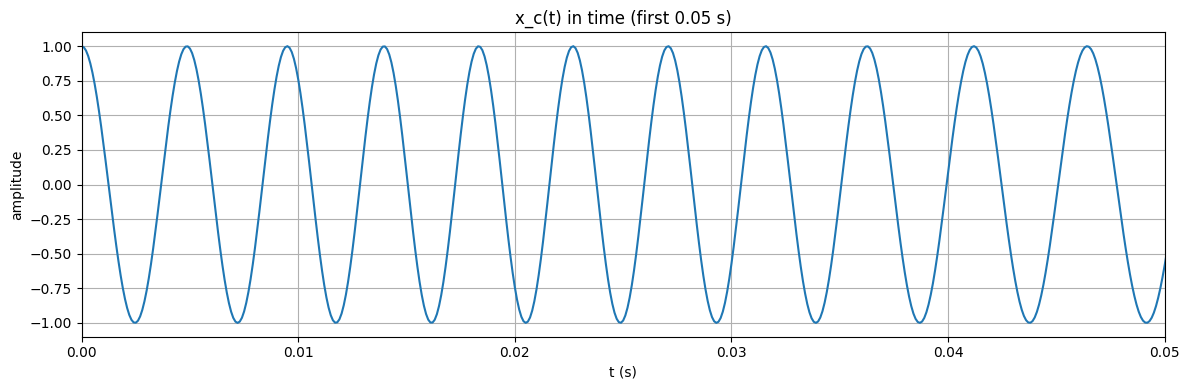

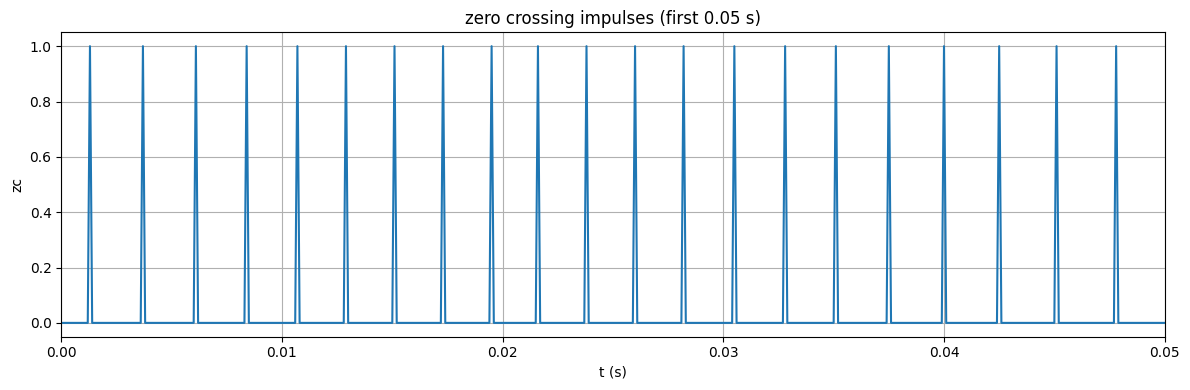

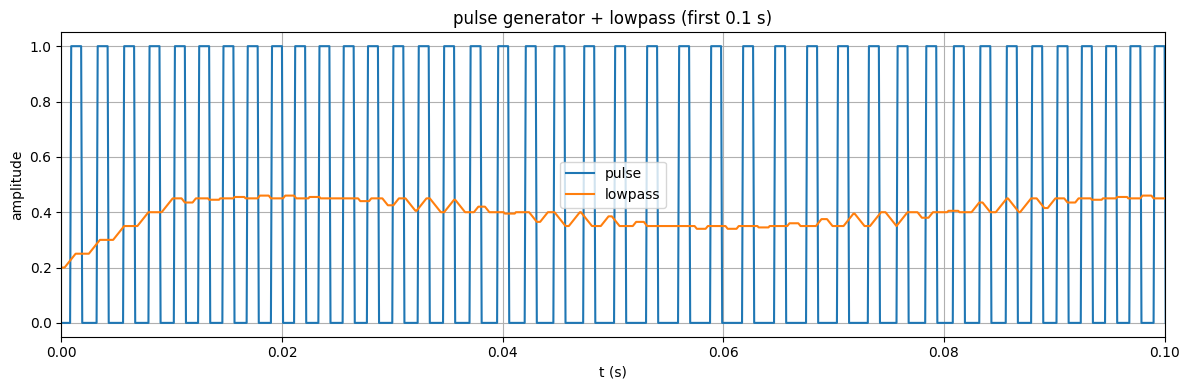

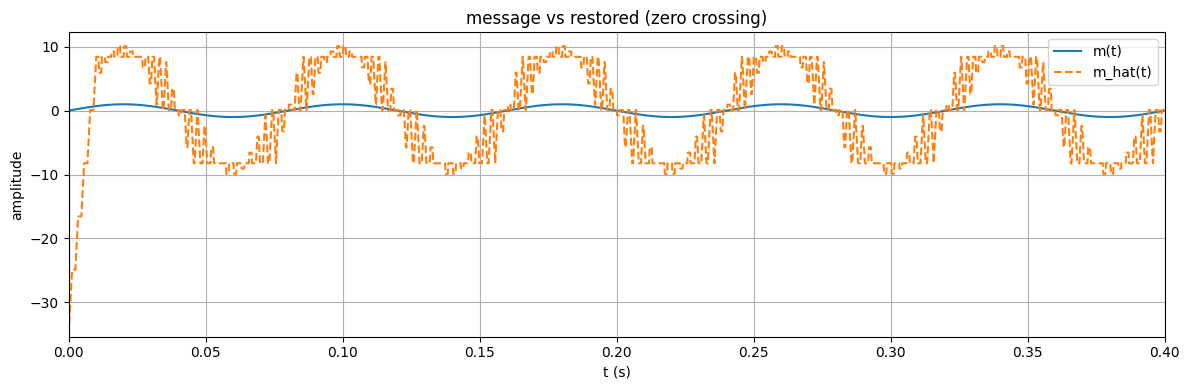

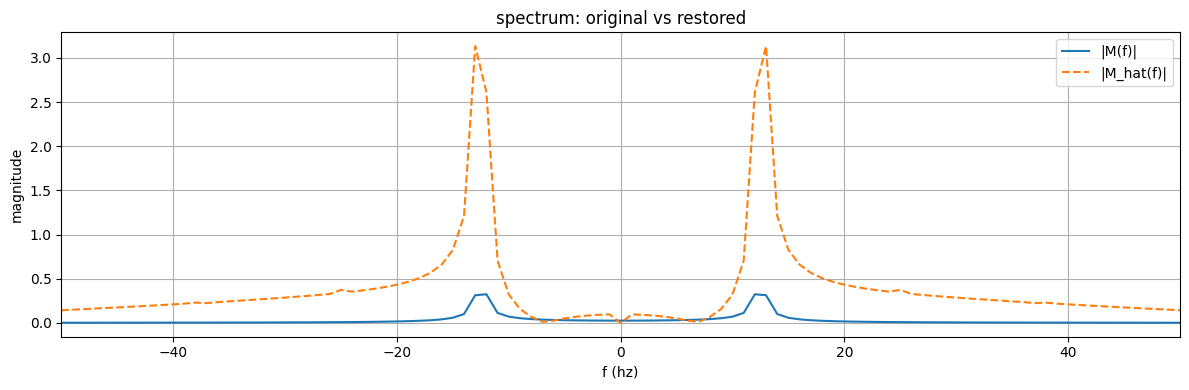

In [25]:
# parameters
fs = 10_000
Ac = 1.0
fc = 200.0
fD = 30.0

# time vetcor
dt = 1 / fs
t = np.arange(0, 1 + dt, dt)

# message signal m
m = np.sin(25 * np.pi * t)

# fm
m_int = np.cumsum(m) * dt
phi = 2 * np.pi * fc * t + 2 * np.pi * fD * m_int
xc = Ac * np.cos(phi)

# zero crossing detector
sgn = np.sign(xc)
sgn[sgn == 0] = 1
dsgn = np.diff(sgn)
zc = np.r_[0, (np.abs(dsgn) > 0).astype(float)]

# pulse generator
Tp = 1e-3
Lp = max(1, int(Tp * fs))
pulse = np.convolve(zc, np.ones(Lp), mode="same")

# lowpass (moving average)
Tw = 2e-2
Nw = max(1, int(Tw * fs))
lp = np.convolve(pulse, np.ones(Nw) / Nw, mode="same")

# freq estimate + dc block
zc_rate = lp * fs
f_inst_hat = zc_rate / 2
m_hat = (f_inst_hat - fc) / fD
m_hat = m_hat - np.mean(m_hat)


# spectrum helper
def spectrum(x, fs):
    n = len(x)
    X = np.fft.fftshift(np.fft.fft(x)) / n
    f = np.fft.fftshift(np.fft.fftfreq(n, d=1 / fs))
    return f, np.abs(X)


f_m, M = spectrum(m, fs)
f_h, H = spectrum(m_hat, fs)

# plots
plt.figure(figsize=(12, 4))
plt.plot(t, xc)
plt.xlim(0, 0.05)
plt.grid(True)
plt.title("x_c(t) in time (first 0.05 s)")
plt.xlabel("t (s)")
plt.ylabel("amplitude")
plt.tight_layout()

plt.figure(figsize=(12, 4))
plt.plot(t, zc)
plt.xlim(0, 0.05)
plt.grid(True)
plt.title("zero crossing impulses (first 0.05 s)")
plt.xlabel("t (s)")
plt.ylabel("zc")
plt.tight_layout()

plt.figure(figsize=(12, 4))
plt.plot(t, pulse, label="pulse")
plt.plot(t, lp, label="lowpass")
plt.xlim(0, 0.1)
plt.grid(True)
plt.title("pulse generator + lowpass (first 0.1 s)")
plt.xlabel("t (s)")
plt.ylabel("amplitude")
plt.legend()
plt.tight_layout()

plt.figure(figsize=(12, 4))
plt.plot(t, m, label="m(t)")
plt.plot(t, m_hat, "--", label="m_hat(t)")
plt.xlim(0, 0.4)
plt.grid(True)
plt.title("message vs restored (zero crossing)")
plt.xlabel("t (s)")
plt.ylabel("amplitude")
plt.legend()
plt.tight_layout()

plt.figure(figsize=(12, 4))
plt.plot(f_m, M, label="|M(f)|")
plt.plot(f_h, H, "--", label="|M_hat(f)|")
plt.xlim(-50, 50)
plt.grid(True)
plt.title("spectrum: original vs restored")
plt.xlabel("f (hz)")
plt.ylabel("magnitude")
plt.legend()
plt.tight_layout()

plt.show()


the fm signal is

$
x_c(t) = A_c \cos\!\left( 2\pi f_c t + 2\pi f_{\Delta} \int_{0}^{t} m(\tau)\, d\tau \right)
$

its instantaneous frequency is

$
f_i(t) = f_c + f_{\Delta} m(t)
$

### zero crossing detector

a zero crossing happens when $x_c(t)$ changes sign. using

$
s(t)=\mathrm{sign}(x_c(t))
$

a crossing produces a jump in $s(t)$, so taking a discrete derivative and absolute value gives impulses at crossings:

$
z[n] \approx \left| s[n]-s[n-1]\right|
$

this produces a train of impulses whose density follows the instantaneous frequency.

### pulse generator

each impulse was widened to a short rectangular pulse of duration $T_p$ so it can be smoothed reliably:

- choose $T_p = 1\,\text{ms}$ (very small compared to $1/f_c$ scale)

### lowpass filter

after pulse generation, a moving-average lowpass with window $T_w$ estimates the local crossing rate.
the time-scale condition is the same idea as envelope detection:

$
\frac{1}{f_c} \ll T_w \ll \frac{1}{f_m^{\max}}
$

here

$
m(t)=\sin(25\pi t)=\sin(2\pi\cdot 12.5\, t)\Rightarrow f_m^{\max}=12.5~\text{hz}
$

so $T_w$ was chosen as

$
T_w = 20~\text{ms}
$

which averages many carrier cycles but still tracks the message.

if the filtered output estimates the number of zero crossings per second as $\widehat{r}_{zc}(t)$, then

$
\widehat{r}_{zc}(t) \approx 2 f_i(t)
$

so

$
\hat f_i(t)=\frac{\widehat{r}_{zc}(t)}{2}
$

and finally

$
\hat m(t)=\frac{\hat f_i(t)-f_c}{f_{\Delta}}
$

### dc block

a dc block was applied by subtracting the mean of $\hat m(t)$ to remove residual offset from the averaging.

the plots show:
- $x_c(t)$ in time
- detected zero crossing impulses
- pulse generator output and its lowpassed version
- $m(t)$ vs $\hat m(t)$ in time
- spectra of $m(t)$ and $\hat m(t)$ for verification


## Task 2.5
On a graph, plot the message, the FM signal of the message, and the messages retrieved in the
three methods.

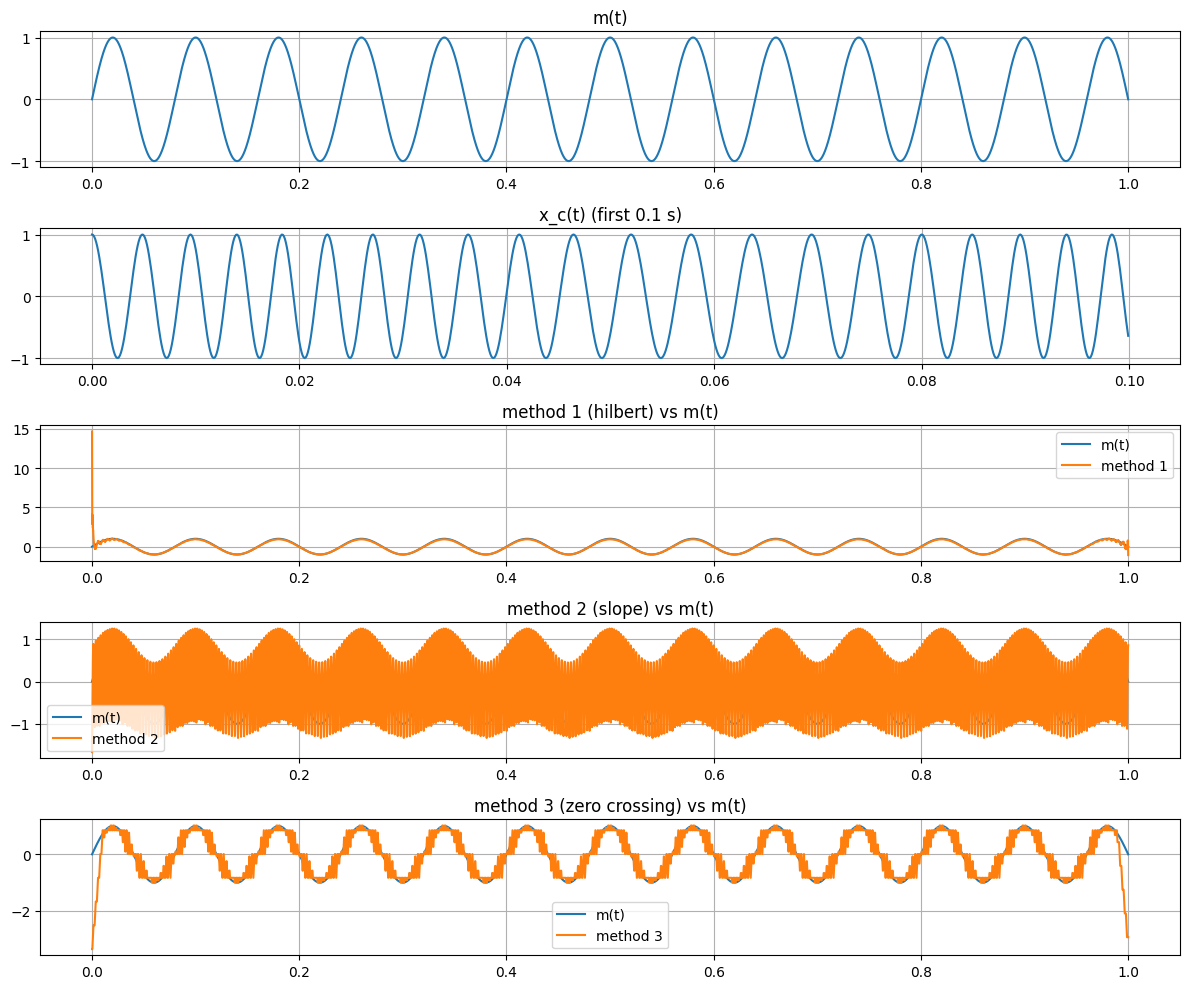

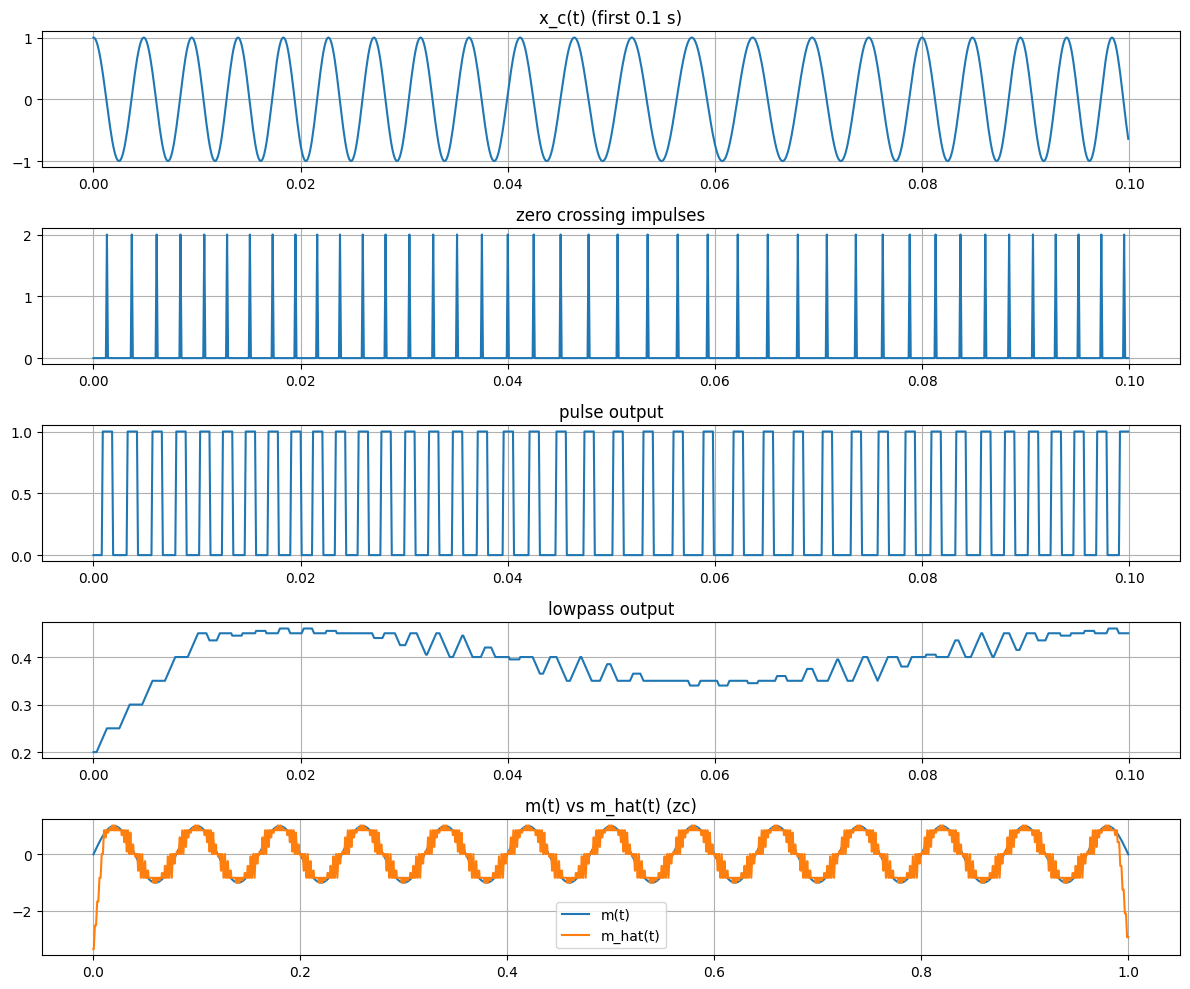

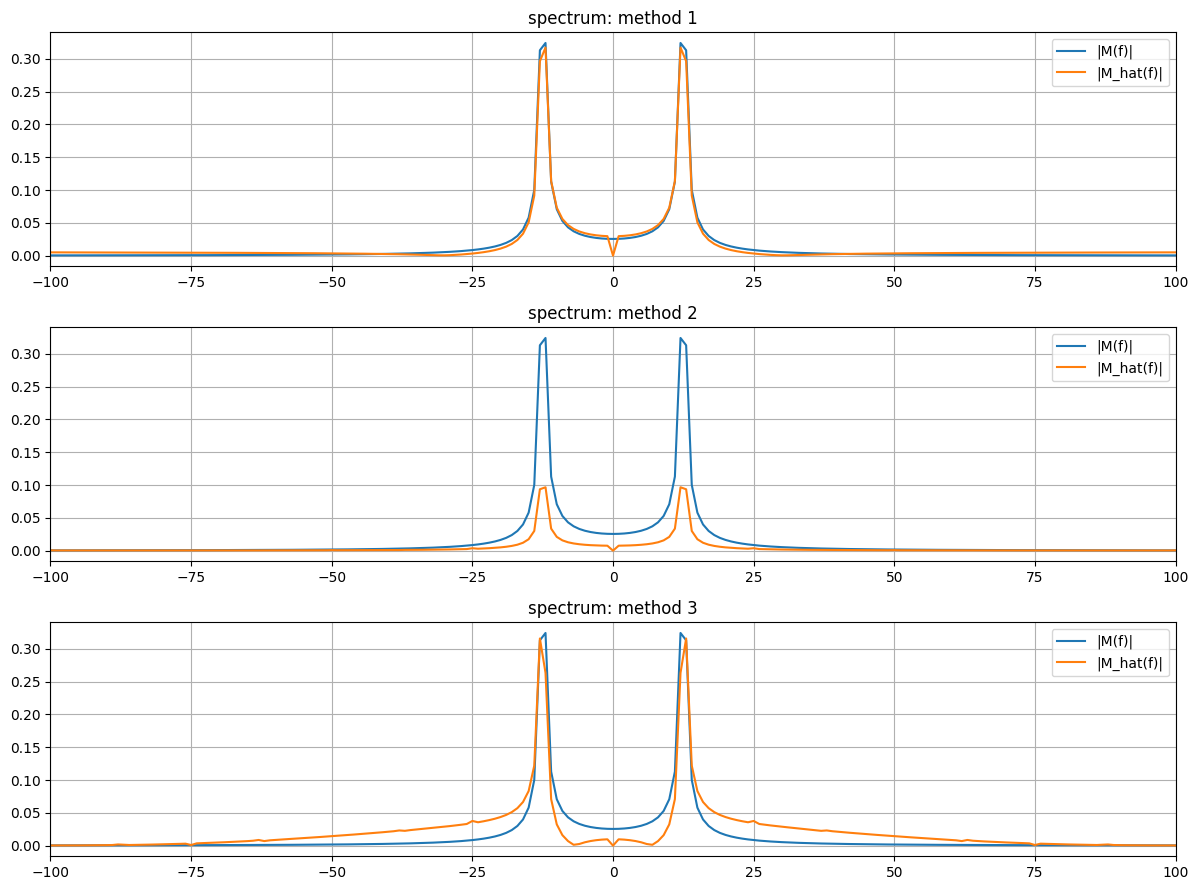

In [30]:
# time
fs = 10_000
dt = 1 / fs
t = np.arange(0, 1 + dt, dt)

# message
m = np.sin(25 * np.pi * t)

# params
Ac = 1.0
fc = 200.0
f_delta = 30.0

# integral
m_int = np.cumsum(m) * dt

# fm
phi = 2 * np.pi * fc * t + 2 * np.pi * f_delta * m_int
x_c = Ac * np.cos(phi)


# fft
def mag_fft(x, fs):
    n = len(x)
    X = np.fft.fftshift(np.fft.fft(x)) / n
    f = np.fft.fftshift(np.fft.fftfreq(n, d=1 / fs))
    return f, np.abs(X)


z = hilbert(x_c)
ph = np.unwrap(np.angle(z))
ph_d = detrend(ph)
m_hil = np.gradient(ph_d, dt) / (2 * np.pi * f_delta)
m_hil = m_hil - np.mean(m_hil)

if np.sum(m_hil ** 2) > 0:
    m_hil *= np.sqrt(np.sum(m ** 2) / np.sum(m_hil ** 2))

x_d = np.gradient(x_c, dt)
xr = np.abs(x_d)

b_env = 200.0
rc = 1 / (2 * np.pi * b_env)
a = np.exp(-dt / rc)

env = np.zeros_like(xr)
env[0] = xr[0]
for n in range(1, len(xr)):
    yd = env[n - 1] * a
    env[n] = max(xr[n], yd)

m_slope = env - np.mean(env)

if np.sum(m_slope ** 2) > 0:
    m_slope *= np.sqrt(np.sum(m ** 2) / np.sum(m_slope ** 2))

s = np.sign(x_c)
s[s == 0] = 1

zc = np.abs(np.diff(s, prepend=s[0]))

Tp = 1e-3
Np = max(1, int(np.round(Tp * fs)))
p = (np.convolve((zc > 0).astype(float), np.ones(Np), mode="same") > 0).astype(float)

Tw = 20e-3
Nw = max(1, int(np.round(Tw * fs)))
p_lpf = np.convolve(p, np.ones(Nw) / Nw, mode="same")

r_zc = (p_lpf * fs) / Np
f_i_hat = r_zc / 2
m_zc = (f_i_hat - fc) / f_delta
m_zc = m_zc - np.mean(m_zc)

if np.sum(m_zc ** 2) > 0:
    m_zc *= np.sqrt(np.sum(m ** 2) / np.sum(m_zc ** 2))

plt.figure(figsize=(12, 10))

plt.subplot(5, 1, 1)
plt.plot(t, m)
plt.title("m(t)")
plt.grid(True)

plt.subplot(5, 1, 2)
plt.plot(t[:int(0.1 * fs)], x_c[:int(0.1 * fs)])
plt.title("x_c(t) (first 0.1 s)")
plt.grid(True)

plt.subplot(5, 1, 3)
plt.plot(t, m, label="m(t)")
plt.plot(t, m_hil, label="method 1")
plt.title("method 1 (hilbert) vs m(t)")
plt.grid(True)
plt.legend()

plt.subplot(5, 1, 4)
plt.plot(t, m, label="m(t)")
plt.plot(t, m_slope, label="method 2")
plt.title("method 2 (slope) vs m(t)")
plt.grid(True)
plt.legend()

plt.subplot(5, 1, 5)
plt.plot(t, m, label="m(t)")
plt.plot(t, m_zc, label="method 3")
plt.title("method 3 (zero crossing) vs m(t)")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 10))

plt.subplot(5, 1, 1)
plt.plot(t[:int(0.1 * fs)], x_c[:int(0.1 * fs)])
plt.title("x_c(t) (first 0.1 s)")
plt.grid(True)

plt.subplot(5, 1, 2)
plt.plot(t[:int(0.1 * fs)], zc[:int(0.1 * fs)])
plt.title("zero crossing impulses")
plt.grid(True)

plt.subplot(5, 1, 3)
plt.plot(t[:int(0.1 * fs)], p[:int(0.1 * fs)])
plt.title("pulse output")
plt.grid(True)

plt.subplot(5, 1, 4)
plt.plot(t[:int(0.1 * fs)], p_lpf[:int(0.1 * fs)])
plt.title("lowpass output")
plt.grid(True)

plt.subplot(5, 1, 5)
plt.plot(t, m, label="m(t)")
plt.plot(t, m_zc, label="m_hat(t)")
plt.title("m(t) vs m_hat(t) (zc)")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

f, M = mag_fft(m, fs)
_, Mh = mag_fft(m_hil, fs)
_, Ms = mag_fft(m_slope, fs)
_, Mz = mag_fft(m_zc, fs)

plt.figure(figsize=(12, 9))

plt.subplot(3, 1, 1)
plt.plot(f, M, label="|M(f)|")
plt.plot(f, Mh, label="|M_hat(f)|")
plt.xlim(-100, 100)
plt.title("spectrum: method 1")
plt.grid(True)
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(f, M, label="|M(f)|")
plt.plot(f, Ms, label="|M_hat(f)|")
plt.xlim(-100, 100)
plt.title("spectrum: method 2")
plt.grid(True)
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(f, M, label="|M(f)|")
plt.plot(f, Mz, label="|M_hat(f)|")
plt.xlim(-100, 100)
plt.title("spectrum: method 3")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


the message $m(t)$, the fm waveform $x_c(t)$, and the recovered messages from the same three methods in tasks 2.2, 2.3, and 2.4 were plotted.

- method 1 (task 2.2): hilbert was used to form the analytic signal, then $\phi(t)$ was unwrapped, detrended to remove the $2\pi f_c t$ term, and differentiated:
$
\hat m(t)\approx \frac{1}{2\pi f_{\Delta}}\frac{d\phi_d(t)}{dt}
$
- method 2 (task 2.3): $x_c(t)$ was differentiated, then an envelope detector was applied to track the amplitude variation caused by $f_i(t)$, and a dc removal was applied.
- method 3 (task 2.4): zero crossings were detected using
$
z[n]\approx |s[n]-s[n-1]|,\quad s(t)=\mathrm{sign}(x_c(t))
$
then each crossing was widened to a pulse with $T_p=1\text{ ms}$, smoothed by a moving-average lowpass with $T_w=20\text{ ms}$, converted to $\hat f_i(t)$, and finally
$
\hat m(t)=\frac{\hat f_i(t)-f_c}{f_{\Delta}}
$
a dc block was done by subtracting the mean.

the comparison was done using separate plots, where each subplot shows $m(t)$ versus the recovered $\hat m(t)$ for one method.


# Question 3: Phase Modulation (PM)
Phase Modulation (PM) is another type of modulation where the phase of the carrier signal is directly modified by the message signal. Unlike Frequency Modulation (FM), where the frequency of the carrier is varied according to the message, in PM, it is the carrier's phase that is shifted in proportion to the message signal. The key difference between PM and FM is that in PM, the instantaneous frequency remains constant, but the phase shifts according to the message signal.

#### **Mathematical Representation of PM:**

The general form of the Phase Modulated signal is given by:

$$
s_{PM}(t) = A \cos\left( 2\pi f_c t + k_p m(t) \right)
$$

Where:
- $ A $ is the amplitude of the carrier,
- $ f_c $ is the carrier frequency,
- $ m(t) $ is the message signal,
- $ k_p $ is the phase modulation sensitivity (how much the phase shifts per unit change in the message signal).

Here, the phase of the carrier $ 2\pi f_c t $ is modulated by $ k_p m(t) $, where the message signal $ m(t) $ directly controls the phase shift. The factor $ k_p $ determines the extent to which the message signal affects the phase of the carrier.

#### **Key Differences Between FM and PM:**
- **Frequency Modulation (FM):** The frequency deviation is proportional to the message signal’s amplitude and changes the carrier's instantaneous frequency.
- **Phase Modulation (PM):** The phase of the carrier is directly shifted in proportion to the message signal’s amplitude, but the carrier’s frequency remains constant.

Thus, in PM, the phase of the carrier is varied continuously over time in response to the message signal, and the instantaneous frequency is related to the derivative of the phase shift.

#### **PM Demodulation and Recovery:**

The demodulation of a Phase Modulated signal follows a similar approach to FM but focuses on recovering the phase information. The key steps in PM demodulation are:

1. **Extracting the Phase:** To recover the original message, we need to first retrieve the phase shift $ \phi(t) = k_p m(t) $ that was applied to the carrier. This is done by differentiating the received PM signal with respect to time. Differentiating the PM signal removes the time factor (the carrier's frequency) and highlights the message signal:
   
   $$
   \frac{d}{dt}\left[ s_{PM}(t) \right] = -2\pi f_c A \sin\left( 2\pi f_c t + k_p m(t) \right) \cdot \left( 2\pi f_c + k_p \frac{dm(t)}{dt} \right)
   $$

2. **Filtering:** After differentiation, the resulting signal contains high-frequency noise that needs to be removed. A low-pass filter is typically applied to the differentiated signal to smooth out the variations and recover the original message signal $ m(t) $.

3. **Rectification (optional):** In some cases, rectification may be applied to ensure that the signal is non-negative and to remove any negative values caused by the sine wave in the differentiation step. This can help in making the message signal more interpretable.



## Task 3.1
We begin by generating the message signal $m(t)$, which is a triangular waveform. The signal is symmetric and rises and falls linearly. The mathematical expression for the triangular pulse is given by:

$$
m(t) = \left\{
  \begin{array}{ll}
  1 - |t/T_a| & \text{for } |t| \leq T_a \\
  0 & \text{otherwise}
  \end{array}
\right.
$$

Here, $T_a = 0.01$ seconds defines the width of the pulse. The signal has a duration of 0.02 seconds (from $-T_a$ to $+T_a$), centered around zero. This triangular waveform will serve as the input message signal for the frequency modulation process.

plot $m(t)$ and it's frequency spectra



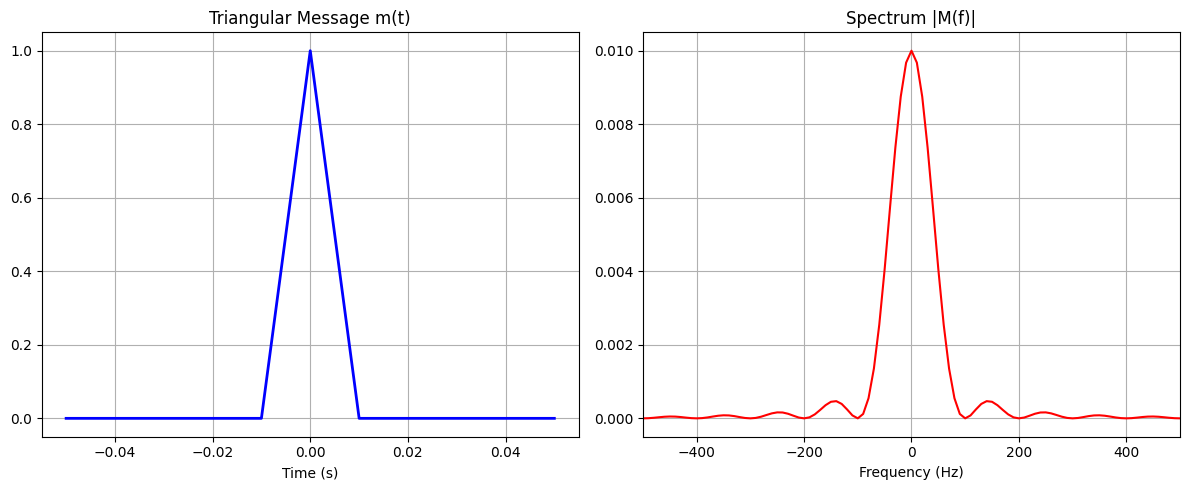

In [33]:
# 1. Setup
t = np.linspace(-0.05, 0.05, 10000) # Time axis
dt = t[1] - t[0]                   # Time step
Ta = 0.01                          # Pulse width

# 2. Triangular signal m(t)
m_t = np.maximum(0, 1 - np.abs(t/Ta)) # Logic implementation

# 3. FFT
M_f = np.fft.fftshift(np.fft.fft(m_t)) * dt # Shift freq
freqs = np.fft.fftshift(np.fft.fftfreq(len(t), d=dt)) # Freq axis

# 4. Plotting
plt.figure(figsize=(12, 5))

# Time domain
plt.subplot(1, 2, 1)
plt.plot(t, m_t, color='blue', lw=2)
plt.title("Triangular Message m(t)")
plt.xlabel("Time (s)")
plt.grid(True)

# Frequency domain
plt.subplot(1, 2, 2)
plt.plot(freqs, np.abs(M_f), color='red')
plt.title("Spectrum |M(f)|")
plt.xlim(-500, 500) # Zoom spectrum
plt.xlabel("Frequency (Hz)")
plt.grid(True)

plt.tight_layout()
plt.show()



the message signal is a triangular pulse centered at zero with width $2T_a$:

$
m(t)=\left\{
\begin{array}{ll}
1-\left|\dfrac{t}{T_a}\right| & |t|\le T_a \\
0 & \text{otherwise}
\end{array}
\right.
$

### setup

a time window of $[-0.05,\,0.05]$ s with $10000$ samples was used, so

$
\Delta t = t[1]-t[0]
$

this $\Delta t$ is needed to scale the fft to approximate the continuous-time fourier transform.

### generating $m(t)$

the triangular waveform was built directly from the definition using a clipped linear expression:

$
m(t)=\max\!\left(0,\;1-\left|\dfrac{t}{T_a}\right|\right)
$

- the term $\left|t/T_a\right|$ makes the shape symmetric.
- the $\max(0,\cdot)$ forces the signal to be zero outside $|t|\le T_a$.

### frequency spectrum

the spectrum was computed using the fft, then shifted so that $f=0$ is in the center:

$
M(f) \approx \Delta t \,\mathrm{FFT}\{m(t)\}
$

- `fftshift` centers the dc component.
- `fftfreq` builds the matching frequency axis from $\Delta t$.

the plotted spectrum is the magnitude:

$
|M(f)|
$

and the x-axis was zoomed to $[-500,\,500]$ hz to show the main lobe and nearby sidelobes clearly.


## Task 3.2

Analyze the results with the following steps:  
(a) Plot  $ s_{\text{PM}}(t) $ and $ m_d(t) $ in the time domain to observe their behavior.  
(b) Plot the frequency spectra of these signals to examine their frequency content.  


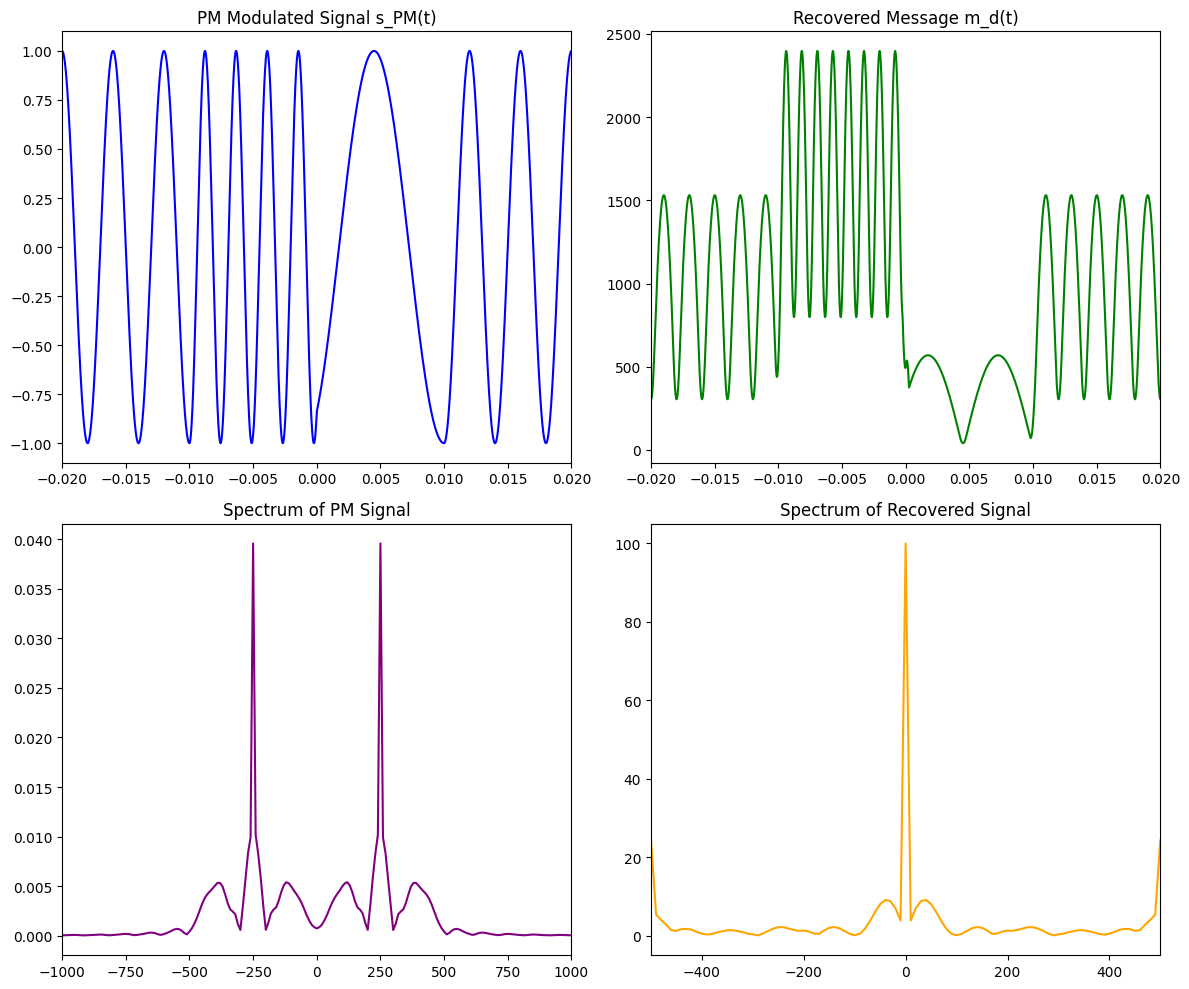

In [34]:
# 1. Parameters
fc = 250
kp = 10
Ac = 1

# 2. PM Modulation
phi_t = kp * m_t
s_pm = Ac * np.cos(2 * np.pi * fc * t + phi_t)

# 3. PM Demodulation (Differentiation + Envelope)
# Step 1: Differentiate
s_diff = np.diff(s_pm, prepend=s_pm[0]) / dt
# Step 2: Envelope detection (Absolute + Low-pass)
m_recovered = np.abs(s_diff)
# Step 3: Filter (Simple moving average for smoothing)
win = 50
m_smooth = np.convolve(m_recovered, np.ones(win)/win, mode='same')

# 4. FFT for Spectra
S_f = np.fft.fftshift(np.fft.fft(s_pm)) * dt
M_rec_f = np.fft.fftshift(np.fft.fft(m_smooth)) * dt

# 5. Plotting
plt.figure(figsize=(12, 10))

# Time Domain: PM and Recovered
plt.subplot(2, 2, 1)
plt.plot(t, s_pm, color='blue')
plt.title("PM Modulated Signal s_PM(t)")
plt.xlim(-0.02, 0.02)

plt.subplot(2, 2, 2)
plt.plot(t, m_smooth, color='green')
plt.title("Recovered Message m_d(t)")
plt.xlim(-0.02, 0.02)

# Frequency Domain
plt.subplot(2, 2, 3)
plt.plot(freqs, np.abs(S_f), color='purple')
plt.title("Spectrum of PM Signal")
plt.xlim(-1000, 1000)

plt.subplot(2, 2, 4)
plt.plot(freqs, np.abs(M_rec_f), color='orange')
plt.title("Spectrum of Recovered Signal")
plt.xlim(-500, 500)

plt.tight_layout()
plt.show()

# Task 3.3
Discuss your observations. How well is the signal recovered? Is there any loss of information due to filtering? What is the impact of isolating the upper or lower sideband on the signal's integrity?



### Time Domain

The PM signal is
$
s_{\mathrm{PM}}(t)=A_c\cos\!\big(2\pi f_c t+k_p m(t)\big)
$

- $A_c$ is constant, so the envelope does not change.
- All information is carried in the phase term $k_p m(t)$.

After differentiation,
$
\frac{d}{dt}s_{\mathrm{PM}}(t)
\approx -A_c\sin\!\big(2\pi f_c t+k_p m(t)\big)
\left(2\pi f_c+k_p \frac{dm(t)}{dt}\right)
$

- the term $k_p\,dm(t)/dt$ contains the message information.
- differentiation amplifies high-frequency components and noise.

Envelope detection gives
$
m_d(t)\;\propto\;\left|2\pi f_c+k_p \frac{dm(t)}{dt}\right|
$

After smoothing,
$
m_d(t)\;\approx\;C\,\frac{dm(t)}{dt}
$

so the recovered signal follows the message shape but with amplitude distortion.



### Frequency Domain

The PM spectrum contains a carrier and symmetric sidebands:
$
S_{\mathrm{PM}}(f)\;\text{has energy at}\; f_c \pm f_m
$

where $f_m$ are the message frequencies.

The spectrum was computed as
$
S(f)\approx \Delta t\,\mathrm{FFT}\{s_{\mathrm{PM}}(t)\}
$

- `fftshift` centers $f=0$.
- `fftfreq` builds the frequency axis from $\Delta t$.

The recovered signal spectrum is
$
M_d(f)\approx \Delta t\,\mathrm{FFT}\{m_d(t)\}
$

and is concentrated near baseband, with higher frequencies attenuated by filtering.


### Effect of Filtering

The moving-average filter acts as a low-pass filter:
$
H(f)=\frac{\sin(\pi f T_w)}{\pi f T_w}
$

- high-frequency components of $m_d(t)$ are reduced.
- sharp transitions in $m(t)$ are smoothed out.

This causes loss of fine details but improves noise suppression.



### Effect of Sideband Isolation

In PM, both sidebands are required:
$
\text{phase information} \;\longleftrightarrow\; \text{spectral symmetry}
$

Removing the upper or lower sideband breaks this symmetry and introduces phase distortion, making accurate recovery impossible.



### Conclusion

- The message is recovered qualitatively but not exactly.
- Differentiation and filtering cause amplitude distortion and information loss.
- Both upper and lower sidebands are essential for preserving PM signal integrity.
